# Out-of-the-Box DeepLabCut Evaluation for XROMM

## Study Goal
Build a reproducible benchmark for out-of-the-box pre-trained DeepLabCut models within the XROMM workflow (X-Ray Of Moving Morphology).

## FAIR Alignment
- **Findable**: each trial receives deterministic split metadata and a global split manifest.
- **Accessible**: all artifacts are written as CSV/JSON in the trial folders.
- **Interoperable**: coordinate schema is preserved from the original `LabeledBodyPartsCoordinates.csv`.
- **Reusable**: split logic is versioned, seed-controlled, and idempotent.

## Input and Output Layout

### Expected Input Per Trial
`{Bird}_{Trial}/CompleteSet/Cam1`, `Cam2`, and `LabeledBodyPartsCoordinates.csv`

### Generated Output Per Trial
- `train/Cam1`, `train/Cam2`, `train/LabeledBodyPartsCoordinates.csv`
- `test/Cam1`, `test/Cam2`, `test/LabeledBodyPartsCoordinates.csv`
- `split_metadata.json` (test/train indices + provenance)

### Global Output
- `Data/split_manifest.csv` summarizing every trial split run

In [1]:
from pathlib import Path
import json
import pandas as pd

from dataset_splitter import split_all_trials, _list_images_sorted
import importlib
import Predictions
import shlex
import subprocess
import sys
from collections import defaultdict
import time

import re

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

import torch
from torchvision import transforms

try:
    import umap
except Exception:
    umap = None
import math

import seaborn as sns


importlib.reload(Predictions)

from Predictions import (
    
    evaluate_within_across_blobdetect_all_birds,
    evaluate_within_across_blobdetect_for_bird,

    evaluate_within_across_all_birds,
    evaluate_within_across_for_bird,
)


from training_sets.dataset_builder import build_three_training_sets_for_all_trials

import training_sets.dataset_builder as dsbuilder


In [2]:
DATA_ROOT = Path(r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCutExperiments\CombinedTrial")


## Make Combined Trials:

In [4]:
from pathlib import Path
import shutil
import pandas as pd

# ----------------------------
# Input folders
# ----------------------------
# trial1_cam1 = Path(r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCutExperiments\Data\Pig_T1\CompleteSet\Cam1")
# trial1_cam2 = Path(r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCutExperiments\Data\Pig_T1\CompleteSet\Cam2")

trial2_cam1 = Path(r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCutExperiments\Data\Pig_T6\CompleteSet\Cam1")
trial2_cam2 = Path(r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCutExperiments\Data\Pig_T6\CompleteSet\Cam2")

trial1_cam1 = Path(r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCutExperiments\CombinedTrial\Pig_T4\CompleteSet\Cam1")
trial1_cam2 = Path(r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCutExperiments\CombinedTrial\Pig_T4\CompleteSet\Cam2")

# csv_trial1 = Path(r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCutExperiments\Data\Pig_T1\CompleteSet\LabeledBodyPartsCoordinates.csv")
csv_trial2 = Path(r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCutExperiments\Data\Pig_T6\CompleteSet\LabeledBodyPartsCoordinates.csv")
csv_trial1 = Path(r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCutExperiments\CombinedTrial\Pig_T4\CompleteSet\LabeledBodyPartsCoordinates.csv")

# ----------------------------
# Output
# ----------------------------
out_cam1 = Path(r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCutExperiments\CombinedTrial\Pig_T46\Cam1")
out_cam2 = Path(r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCutExperiments\CombinedTrial\Pig_T46\Cam2")
out_cam1.mkdir(parents=True, exist_ok=True)
out_cam2.mkdir(parents=True, exist_ok=True)

out_csv = Path(r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCutExperiments\CombinedTrial\Pig_T46\Labels.csv")

# ----------------------------
# Helper
# ----------------------------
def sorted_images(folder):
    return sorted(
        [p for p in folder.iterdir() if p.suffix.lower() in [".png", ".jpg", ".jpeg", ".bmp"]],
        key=lambda x: x.name
    )

cam1_files = sorted_images(trial1_cam1) + sorted_images(trial2_cam1)
cam2_files = sorted_images(trial1_cam2) + sorted_images(trial2_cam2)

assert len(cam1_files) == len(cam2_files), "Camera folders have different numbers of images."

# ----------------------------
# Copy images with new numbering
# ----------------------------
for i, (img1, img2) in enumerate(zip(cam1_files, cam2_files)):
    ext1 = img1.suffix
    ext2 = img2.suffix

    shutil.copy2(img1, out_cam1 / f"{i:06d}{ext1}")
    shutil.copy2(img2, out_cam2 / f"{i:06d}{ext2}")

# ----------------------------
# Merge CSVs
# ----------------------------
df1 = pd.read_csv(csv_trial1)
df2 = pd.read_csv(csv_trial2)

assert len(df1) == len(sorted_images(trial1_cam1))
assert len(df2) == len(sorted_images(trial2_cam1))

merged = pd.concat([df1, df2], ignore_index=True)
merged.to_csv(out_csv, index=False)

print(f"Merged {len(merged)} samples.")

Merged 2000 samples.


## Manifest DF Creation

In [6]:
# Reproducible split settings

TEST_FRAME_COUNT = 300
SEED = 42
OVERWRITE_EXISTING_SPLITS = False

DATA_ROOT

WindowsPath('C:/Users/Salle-Cineradio/Documents/MachineLearning/BirdSongs-MNHN/Testing/DeepLabCutExperiments/CombinedTrial')

In [51]:
from pathlib import Path

data_dir = Path(
    r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN"
    r"\Testing\DeepLabCutExperiments\Data"
)

for trial_dir in data_dir.glob("*_T*"):
    complete_set = trial_dir / "CompleteSet"
    cam1_dir = complete_set / "Cam1"
    cam2_dir = complete_set / "Cam2"

    cam1_images = _list_images_sorted(cam1_dir)
    cam2_images = _list_images_sorted(cam2_dir)

    available = min(
        len(cam1_images),
        len(cam2_images),

    )

    print(trial_dir.name, available)


DB_T15 2980
DB_T1516 3742
DB_T1517 4540
DB_T16 762
DB_T1617 2322
DB_T17 1560
Pig_T1 425
Pig_T4 1120
Pig_T41 1545
Pig_T46 2000
Pig_T6 880
Pig_T61 1305
Tulio_T10 2849
Tulio_T105 4078
Tulio_T106 3528
Tulio_T5 1229
Tulio_T56 1908
Tulio_T6 679


In [56]:
db_frames = (2980+760+1560)
tulio_frames = 2849+1229+679
piG_FRAMES = (425 + 1120 + 880)
print("total_average", (db_frames + tulio_frames + piG_FRAMES)/9)
print("canary_average", (db_frames + tulio_frames ))
piG_FRAMES

total_average 1386.888888888889
canary_average 10057


2425

In [7]:
manifest_df = split_all_trials(
    data_root=DATA_ROOT,
    test_frame_count=TEST_FRAME_COUNT,
    seed=SEED,
    overwrite=OVERWRITE_EXISTING_SPLITS,
)

manifest_df

,trial_name,trial_path,available_frames,requested_test_frames,selected_test_frames,selected_train_frames,skipped,reason
0,Pig_T4,C:\Users\Salle-Cineradio\Documents\MachineLear...,1120,300,300,820,False,
1,Pig_T41,C:\Users\Salle-Cineradio\Documents\MachineLear...,1545,300,300,1245,False,
2,Pig_T46,C:\Users\Salle-Cineradio\Documents\MachineLear...,2000,300,300,1700,False,
3,Pig_T61,C:\Users\Salle-Cineradio\Documents\MachineLear...,1305,300,300,1005,False,


In [5]:
# manifest_df = pd.read_csv(r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCutExperiments\Data\split_manifest.csv").iloc[:, 1:]

In [9]:
# Quick quality checks
summary = {
    "n_trials": int(len(manifest_df)),
    "n_skipped": int(manifest_df["skipped"].sum()) if "skipped" in manifest_df.columns else 0,
    "n_processed": int((~manifest_df["skipped"]).sum()) if "skipped" in manifest_df.columns else int(len(manifest_df)),
}
summary

{'n_trials': 4, 'n_skipped': 0, 'n_processed': 4}

In [10]:
# Inspect one trial metadata file to verify indices are stored
trial_dirs = sorted([p for p in DATA_ROOT.iterdir() if p.is_dir()])
sample_trial = trial_dirs[0] if trial_dirs else None
if sample_trial is None:
    raise RuntimeError("No trial folders found under DATA_ROOT")

metadata_path = sample_trial / "split_metadata.json"
metadata = json.loads(metadata_path.read_text(encoding="utf-8"))
metadata

{'version': 1,
 'created_unix': 1786061487,
 'trial_name': 'Pig_T4',
 'trial_path': 'C:\\Users\\Salle-Cineradio\\Documents\\MachineLearning\\BirdSongs-MNHN\\Testing\\DeepLabCutExperiments\\CombinedTrial\\Pig_T4',
 'seed': 42,
 'test_frame_count_requested': 300,
 'available_frames_used': 1120,
 'cam1_image_count': 1120,
 'cam2_image_count': 1120,
 'csv_row_count': 1120,
 'test_indices': [1,
  4,
  6,
  7,
  13,
  14,
  16,
  19,
  23,
  30,
  39,
  43,
  50,
  51,
  54,
  61,
  64,
  65,
  73,
  81,
  85,
  88,
  90,
  93,
  96,
  102,
  103,
  104,
  110,
  114,
  116,
  117,
  118,
  119,
  120,
  124,
  130,
  131,
  135,
  138,
  139,
  140,
  141,
  142,
  145,
  146,
  148,
  150,
  154,
  161,
  163,
  164,
  167,
  175,
  178,
  186,
  189,
  191,
  193,
  198,
  200,
  201,
  204,
  206,
  209,
  210,
  212,
  217,
  219,
  223,
  224,
  228,
  229,
  234,
  236,
  245,
  247,
  255,
  257,
  261,
  262,
  267,
  268,
  270,
  271,
  275,
  283,
  285,
  287,
  292,
  303,
  30

## Build Three Training Sets Per Trial (Dataset Creation Only)

From each trial's `train/` split, create model-input subsets:

- `random_train`
- `displacement_train` (zone size 150)
- `dino_train`

This stage mirrors `train_update_model` setup through dataset creation and **stops before model training** (`dlcs.create_and_train`).

In [11]:

TRAINING_NFRAMES = (100, 50)
TRAINING_EPOCHS = 125
TRAINING_SEED = 42
DISPLACEMENT_ZONE_SIZE = 150

TRAINING_NFRAMES, TRAINING_EPOCHS, TRAINING_SEED, DISPLACEMENT_ZONE_SIZE

((100, 50), 125, 42, 150)

In [12]:
training_manifest_df = build_three_training_sets_for_all_trials(
    data_root=DATA_ROOT,
    nframes_values=TRAINING_NFRAMES,
    epochs=TRAINING_EPOCHS,
    frame_selection_seed=TRAINING_SEED,
    zone_size=DISPLACEMENT_ZONE_SIZE,
)

training_manifest_df

Using cache found in C:\Users\Salle-Cineradio/.cache\torch\hub\facebookresearch_dinov2_main
C:\Users\Salle-Cineradio/.cache\torch\hub\facebookresearch_dinov2_main\dinov2\layers\swiglu_ffn.py:51: UserWarning: xFormers is not available (SwiGLU)
  warnings.warn("xFormers is not available (SwiGLU)")
C:\Users\Salle-Cineradio/.cache\torch\hub\facebookresearch_dinov2_main\dinov2\layers\attention.py:33: UserWarning: xFormers is not available (Attention)
  warnings.warn("xFormers is not available (Attention)")
C:\Users\Salle-Cineradio/.cache\torch\hub\facebookresearch_dinov2_main\dinov2\layers\block.py:40: UserWarning: xFormers is not available (Block)
  warnings.warn("xFormers is not available (Block)")


Loading DLC 3.0.0rc13...
DLC loaded in light mode; you cannot use any GUI (labeling, relabeling and standalone GUI)
Created "C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCutExperiments\CombinedTrial\Pig_T4\random_train\nframes_100\ModelsToTune\Canari-FineTuner-2026-08-07\videos"
Created "C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCutExperiments\CombinedTrial\Pig_T4\random_train\nframes_100\ModelsToTune\Canari-FineTuner-2026-08-07\labeled-data"
Created "C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCutExperiments\CombinedTrial\Pig_T4\random_train\nframes_100\ModelsToTune\Canari-FineTuner-2026-08-07\training-datasets"
Created "C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCutExperiments\CombinedTrial\Pig_T4\random_train\nframes_100\ModelsToTune\Canari-FineTuner-2026-08-07\dlc-models"
Attempting to create a symbolic link of the video ...
Symlink c

Using cache found in C:\Users\Salle-Cineradio/.cache\torch\hub\facebookresearch_dinov2_main


Created "C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCutExperiments\CombinedTrial\Pig_T4\random_train\nframes_50\ModelsToTune\Canari-FineTuner-2026-08-07\videos"
Created "C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCutExperiments\CombinedTrial\Pig_T4\random_train\nframes_50\ModelsToTune\Canari-FineTuner-2026-08-07\labeled-data"
Created "C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCutExperiments\CombinedTrial\Pig_T4\random_train\nframes_50\ModelsToTune\Canari-FineTuner-2026-08-07\training-datasets"
Created "C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCutExperiments\CombinedTrial\Pig_T4\random_train\nframes_50\ModelsToTune\Canari-FineTuner-2026-08-07\dlc-models"
Attempting to create a symbolic link of the video ...
Symlink creation impossible (exFat architecture?): copying the video instead.
C:\Users\Salle-Cineradio\Documents\MachineLearning\

Using cache found in C:\Users\Salle-Cineradio/.cache\torch\hub\facebookresearch_dinov2_main


...

Using cache found in C:\Users\Salle-Cineradio/.cache\torch\hub\facebookresearch_dinov2_main


Created "C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCutExperiments\CombinedTrial\Pig_T61\random_train\nframes_100\ModelsToTune\Canari-FineTuner-2026-08-07\videos"
Created "C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCutExperiments\CombinedTrial\Pig_T61\random_train\nframes_100\ModelsToTune\Canari-FineTuner-2026-08-07\labeled-data"
Created "C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCutExperiments\CombinedTrial\Pig_T61\random_train\nframes_100\ModelsToTune\Canari-FineTuner-2026-08-07\training-datasets"
Created "C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCutExperiments\CombinedTrial\Pig_T61\random_train\nframes_100\ModelsToTune\Canari-FineTuner-2026-08-07\dlc-models"
Attempting to create a symbolic link of the video ...
Symlink creation impossible (exFat architecture?): copying the video instead.
C:\Users\Salle-Cineradio\Documents\MachineL

Using cache found in C:\Users\Salle-Cineradio/.cache\torch\hub\facebookresearch_dinov2_main


Created "C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCutExperiments\CombinedTrial\Pig_T61\random_train\nframes_50\ModelsToTune\Canari-FineTuner-2026-08-07\videos"
Created "C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCutExperiments\CombinedTrial\Pig_T61\random_train\nframes_50\ModelsToTune\Canari-FineTuner-2026-08-07\labeled-data"
Created "C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCutExperiments\CombinedTrial\Pig_T61\random_train\nframes_50\ModelsToTune\Canari-FineTuner-2026-08-07\training-datasets"
Created "C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCutExperiments\CombinedTrial\Pig_T61\random_train\nframes_50\ModelsToTune\Canari-FineTuner-2026-08-07\dlc-models"
Attempting to create a symbolic link of the video ...
Symlink creation impossible (exFat architecture?): copying the video instead.
C:\Users\Salle-Cineradio\Documents\MachineLearn

,trial_folder,bird,trial_num,method,nframes,epochs,output_root,config_path,selection_count,status,message
0,Pig_T4,Pig,4,random,100,125,C:\Users\Salle-Cineradio\Documents\MachineLear...,C:\Users\Salle-Cineradio\Documents\MachineLear...,100,ok,Combined DLC dataset created
1,Pig_T4,Pig,4,displacement,100,125,C:\Users\Salle-Cineradio\Documents\MachineLear...,C:\Users\Salle-Cineradio\Documents\MachineLear...,100,ok,Combined DLC dataset created
2,Pig_T4,Pig,4,dino,100,125,C:\Users\Salle-Cineradio\Documents\MachineLear...,C:\Users\Salle-Cineradio\Documents\MachineLear...,100,ok,Combined DLC dataset created
3,Pig_T4,Pig,4,random,50,125,C:\Users\Salle-Cineradio\Documents\MachineLear...,C:\Users\Salle-Cineradio\Documents\MachineLear...,50,ok,Combined DLC dataset created
4,Pig_T4,Pig,4,displacement,50,125,C:\Users\Salle-Cineradio\Documents\MachineLear...,C:\Users\Salle-Cineradio\Documents\MachineLear...,50,ok,Combined DLC dataset created
5,Pig_T4,Pig,4,dino,50,125,C:\Users\Salle-Cineradio\Documents\MachineLear...,C:\Users\Salle-Cineradio\Documents\MachineLear...,50,ok,Combined DLC dataset created
6,Pig_T41,Pig,41,random,100,125,C:\Users\Salle-Cineradio\Documents\MachineLear...,C:\Users\Salle-Cineradio\Documents\MachineLear...,100,ok,Combined DLC dataset created
7,Pig_T41,Pig,41,displacement,100,125,C:\Users\Salle-Cineradio\Documents\MachineLear...,C:\Users\Salle-Cineradio\Documents\MachineLear...,100,ok,Combined DLC dataset created
8,Pig_T41,Pig,41,dino,100,125,C:\Users\Salle-Cineradio\Documents\MachineLear...,C:\Users\Salle-Cineradio\Documents\MachineLear...,100,ok,Combined DLC dataset created
9,Pig_T41,Pig,41,random,50,125,C:\Users\Salle-Cineradio\Documents\MachineLear...,C:\Users\Salle-Cineradio\Documents\MachineLear...,50,ok,Combined DLC dataset created


## Provenance Notes

- Splits are deterministic from `SEED=42`.
- If Cam1/Cam2/CSV lengths differ, the split uses the aligned minimum count to maintain row-image correspondence.
- This notebook is designed for repeated reruns as new trial folders are added to `Data/`.

## Next Benchmark Steps

1. Train/evaluate out-of-the-box pretrained DeepLabCut models on each split.
2. Compute per-trial and pooled error metrics against held-out `test` labels.
3. Export a model-comparison table and publication figures with confidence intervals.
4. Record software/version metadata for full reproducibility in manuscript supplements.

## Embedding Comparison of Split Usage

This reproduces the embedding scatter view for one trial:

- all images in dark background points
- bright overlays for selected frames from `random_train`, `displacement_train`, `dino_train`
- bright overlay for held-out `test` frames

In [3]:


TRIAL_FOR_EMBED_VIS = "Pig_T6"  # Example: DB_T15, DB_T16, DB_T17, Tulio_T10, Tulio_T5
NFRAMES_FOR_METHOD_METADATA = 50  # pick 100 or 50
CAMERA_FOR_EMBED_VIS = "Cam1"

DINO_BATCH_SIZE = 32
DINO_MODEL_NAME = "dinov2_vits14"
UMAP_NEIGHBORS = 15
UMAP_MIN_DIST = 0.1
UMAP_METRIC = "cosine"
RANDOM_SEED = 42


In [4]:


def _image_sort_key(path: Path) -> tuple[int, str]:
    match = re.search(r"(\d+)(?!.*\d)", path.stem)
    idx = int(match.group(1)) if match else -1
    return idx, path.name.lower()


def _list_images_sorted(folder: Path) -> list[Path]:
    exts = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff"}
    return sorted([p for p in folder.iterdir() if p.is_file() and p.suffix.lower() in exts], key=_image_sort_key)


def _read_selected_indices(trial_dir: Path, method_name: str, nframes: int) -> list[int]:
    metadata_path = trial_dir / f"{method_name}_train" / f"nframes_{int(nframes)}" / "dataset_build_metadata.json"
    if not metadata_path.exists():
        return []
    data = json.loads(metadata_path.read_text(encoding="utf-8"))
    return [int(x) for x in data.get("selected_indices", [])]


def _load_split_test_filenames(trial_dir: Path, camera: str = "Cam1") -> set[str]:
    test_dir = trial_dir / "test" / camera
    return {p.name for p in _list_images_sorted(test_dir)}


def _compute_dino_embeddings(image_paths: list[Path], batch_size: int = 32, model_name: str = "dinov2_vits14") -> np.ndarray:
    if not image_paths:
        raise ValueError("No images found for embedding computation")

    device = "cuda" if torch.cuda.is_available() else "cpu"
    model = torch.hub.load("facebookresearch/dinov2", model_name)
    model.eval().to(device)

    transform = transforms.Compose(
        [
            transforms.Resize((224, 224)),
            transforms.ToTensor(),
            transforms.Normalize(mean=(0.5, 0.5, 0.5), std=(0.5, 0.5, 0.5)),
        ]
    )

    all_feats = []
    for start in range(0, len(image_paths), int(batch_size)):
        batch_paths = image_paths[start : start + int(batch_size)]
        batch_tensors = []
        for image_path in batch_paths:
            with Image.open(image_path) as image_file:
                batch_tensors.append(transform(image_file.convert("RGB")))
        batch = torch.stack(batch_tensors).to(device)
        with torch.no_grad():
            feats = model(batch)
        all_feats.append(feats.detach().cpu())

    embeddings = torch.cat(all_feats, dim=0)
    embeddings = embeddings / embeddings.norm(dim=1, keepdim=True).clamp_min(1e-12)
    return embeddings.numpy()



In [9]:
from pathlib import Path
import numpy as np
import pandas as pd


# ============================================================
# SETTINGS
# ============================================================

DATA_ROOT = Path(
    r"C:\Users\Salle-Cineradio\Documents\MachineLearning"
    r"\BirdSongs-MNHN\Testing\DeepLabCutExperiments\Data"
)

# List of trials to process
TRIAL_DIRS = [
    "Pig_T6",
    "DB_T17",
    "Tulio_T10",
]

CAMERA_FOR_EMBED_VIS = "Camera1"

# Existing settings from your script
DINO_BATCH_SIZE = 32
DINO_MODEL_NAME = "dinov2_vits14"

UMAP_NEIGHBORS = 15
UMAP_MIN_DIST = 0.1
UMAP_METRIC = "euclidean"

RANDOM_SEED = 42

NFRAMES_FOR_METHOD_METADATA = 100


# ============================================================
# PROCESS ONE TRIAL
# ============================================================

def compute_trial_embeddings(
    trial_name,
    camera = "Cam1",
):
    """
    Compute DINO embeddings for all complete-set images
    in one trial.

    Returns a dictionary containing:

        trial
        camera
        image_paths
        image_names
        embeddings
        embedding_2d
        method_to_indices
        test_indices
    """

    trial_dir = DATA_ROOT / trial_name

    if not trial_dir.exists():
        raise FileNotFoundError(
            f"Trial folder not found: {trial_dir}"
        )

    complete_cam_dir = (
        trial_dir
        / "CompleteSet"
        / camera
    )

    train_cam_dir = (
        trial_dir
        / "train"
        / camera
    )

    # --------------------------------------------------------
    # Find images
    # --------------------------------------------------------

    complete_images = _list_images_sorted(
        complete_cam_dir
    )

    train_images = _list_images_sorted(
        train_cam_dir
    )

    if not complete_images:
        raise RuntimeError(
            f"No complete-set images found in: "
            f"{complete_cam_dir}"
        )

    if not train_images:
        raise RuntimeError(
            f"No train-set images found in: "
            f"{train_cam_dir}"
        )

    # --------------------------------------------------------
    # DINO embeddings
    # --------------------------------------------------------

    embeddings = _compute_dino_embeddings(
        complete_images,
        batch_size=DINO_BATCH_SIZE,
        model_name=DINO_MODEL_NAME,
    )

    embeddings = np.asarray(embeddings)

    # --------------------------------------------------------
    # 2D representation
    # --------------------------------------------------------

    if umap is not None:

        reducer = umap.UMAP(
            n_neighbors=UMAP_NEIGHBORS,
            min_dist=UMAP_MIN_DIST,
            metric=UMAP_METRIC,
            random_state=RANDOM_SEED,
        )

        embedding_2d = reducer.fit_transform(
            embeddings
        )

    else:

        from sklearn.decomposition import PCA

        pca = PCA(
            n_components=2,
            random_state=RANDOM_SEED,
        )

        embedding_2d = pca.fit_transform(
            embeddings
        )

    # --------------------------------------------------------
    # Map image names -> complete-set indices
    # --------------------------------------------------------

    complete_name_to_idx = {
        p.name: i
        for i, p in enumerate(complete_images)
    }

    train_name_list = [
        p.name
        for p in train_images
    ]

    # --------------------------------------------------------
    # Selected training images
    # --------------------------------------------------------

    method_to_indices = {}

    for method in (
        "random",
        "displacement",
        "dino",
    ):

        train_local_indices = (
            _read_selected_indices(
                trial_dir,
                method,
                NFRAMES_FOR_METHOD_METADATA,
            )
        )

        selected_names = [
            train_name_list[i]
            for i in train_local_indices
            if 0 <= i < len(train_name_list)
        ]

        method_to_indices[method] = np.asarray(
            [
                complete_name_to_idx[name]
                for name in selected_names
                if name in complete_name_to_idx
            ],
            dtype=int,
        )

    # --------------------------------------------------------
    # Test images
    # --------------------------------------------------------

    test_names = _load_split_test_filenames(
        trial_dir,
        camera,
    )

    test_indices = np.asarray(
        [
            complete_name_to_idx[name]
            for name in test_names
            if name in complete_name_to_idx
        ],
        dtype=int,
    )

    # --------------------------------------------------------
    # Print summary
    # --------------------------------------------------------

    print(
        {
            "trial": trial_name,
            "camera": camera,
            "n_all_images": len(complete_images),
            "embedding_shape": embeddings.shape,
            "n_random": int(
                method_to_indices["random"].size
            ),
            "n_displacement": int(
                method_to_indices["displacement"].size
            ),
            "n_dino": int(
                method_to_indices["dino"].size
            ),
            "n_test": int(test_indices.size),
            "reducer": (
                "UMAP"
                if umap is not None
                else "PCA (fallback)"
            ),
        }
    )

    # --------------------------------------------------------
    # Return everything
    # --------------------------------------------------------

    return {
        "trial": trial_name,
        "camera": camera,

        "image_paths": complete_images,
        "image_names": [
            p.name
            for p in complete_images
        ],

        # Original DINO embeddings
        "embeddings": embeddings,

        # 2D UMAP/PCA coordinates
        "embedding_2d": embedding_2d,

        # Indices into embeddings
        "method_to_indices": method_to_indices,
        "test_indices": test_indices,
    }


# ============================================================
# RUN ALL TRIALS
# ============================================================

embedding_results = []

for trial_name in TRIAL_DIRS:

    print("\n" + "=" * 70)
    print(f"PROCESSING {trial_name}")
    print("=" * 70)

    result = compute_trial_embeddings(
        trial_name=trial_name,
        # camera=CAMERA_FOR_EMBED_VIS,
    )

    embedding_results.append(result)


# ============================================================
# SUMMARY
# ============================================================

print("\n" + "=" * 70)
print("ALL TRIALS COMPLETE")
print("=" * 70)

for result in embedding_results:

    print(
        result["trial"],
        result["embeddings"].shape,
        result["embedding_2d"].shape,
    )


PROCESSING Pig_T6


Using cache found in C:\Users\Salle-Cineradio/.cache\torch\hub\facebookresearch_dinov2_main
c:\Users\Salle-Cineradio\Documents\miniconda\envs\DEEPLABCUT\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


{'trial': 'Pig_T6', 'camera': 'Cam1', 'n_all_images': 880, 'embedding_shape': (880, 384), 'n_random': 100, 'n_displacement': 100, 'n_dino': 100, 'n_test': 300, 'reducer': 'UMAP'}

PROCESSING DB_T17


Using cache found in C:\Users\Salle-Cineradio/.cache\torch\hub\facebookresearch_dinov2_main
c:\Users\Salle-Cineradio\Documents\miniconda\envs\DEEPLABCUT\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


{'trial': 'DB_T17', 'camera': 'Cam1', 'n_all_images': 1560, 'embedding_shape': (1560, 384), 'n_random': 100, 'n_displacement': 100, 'n_dino': 100, 'n_test': 300, 'reducer': 'UMAP'}

PROCESSING Tulio_T10


Using cache found in C:\Users\Salle-Cineradio/.cache\torch\hub\facebookresearch_dinov2_main
c:\Users\Salle-Cineradio\Documents\miniconda\envs\DEEPLABCUT\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


{'trial': 'Tulio_T10', 'camera': 'Cam1', 'n_all_images': 2849, 'embedding_shape': (2849, 384), 'n_random': 100, 'n_displacement': 100, 'n_dino': 100, 'n_test': 300, 'reducer': 'UMAP'}

ALL TRIALS COMPLETE
Pig_T6 (880, 384) (880, 2)
DB_T17 (1560, 384) (1560, 2)
Tulio_T10 (2849, 384) (2849, 2)


In [25]:
import pickle

OUTPUT_EMBEDDINGS = DATA_ROOT / "embedding_results.pkl"

with open(OUTPUT_EMBEDDINGS, "wb") as f:
    pickle.dump(embedding_results, f)

print(f"Saved embeddings to:\n{OUTPUT_EMBEDDINGS}")

Saved embeddings to:
C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCutExperiments\Data\embedding_results.pkl


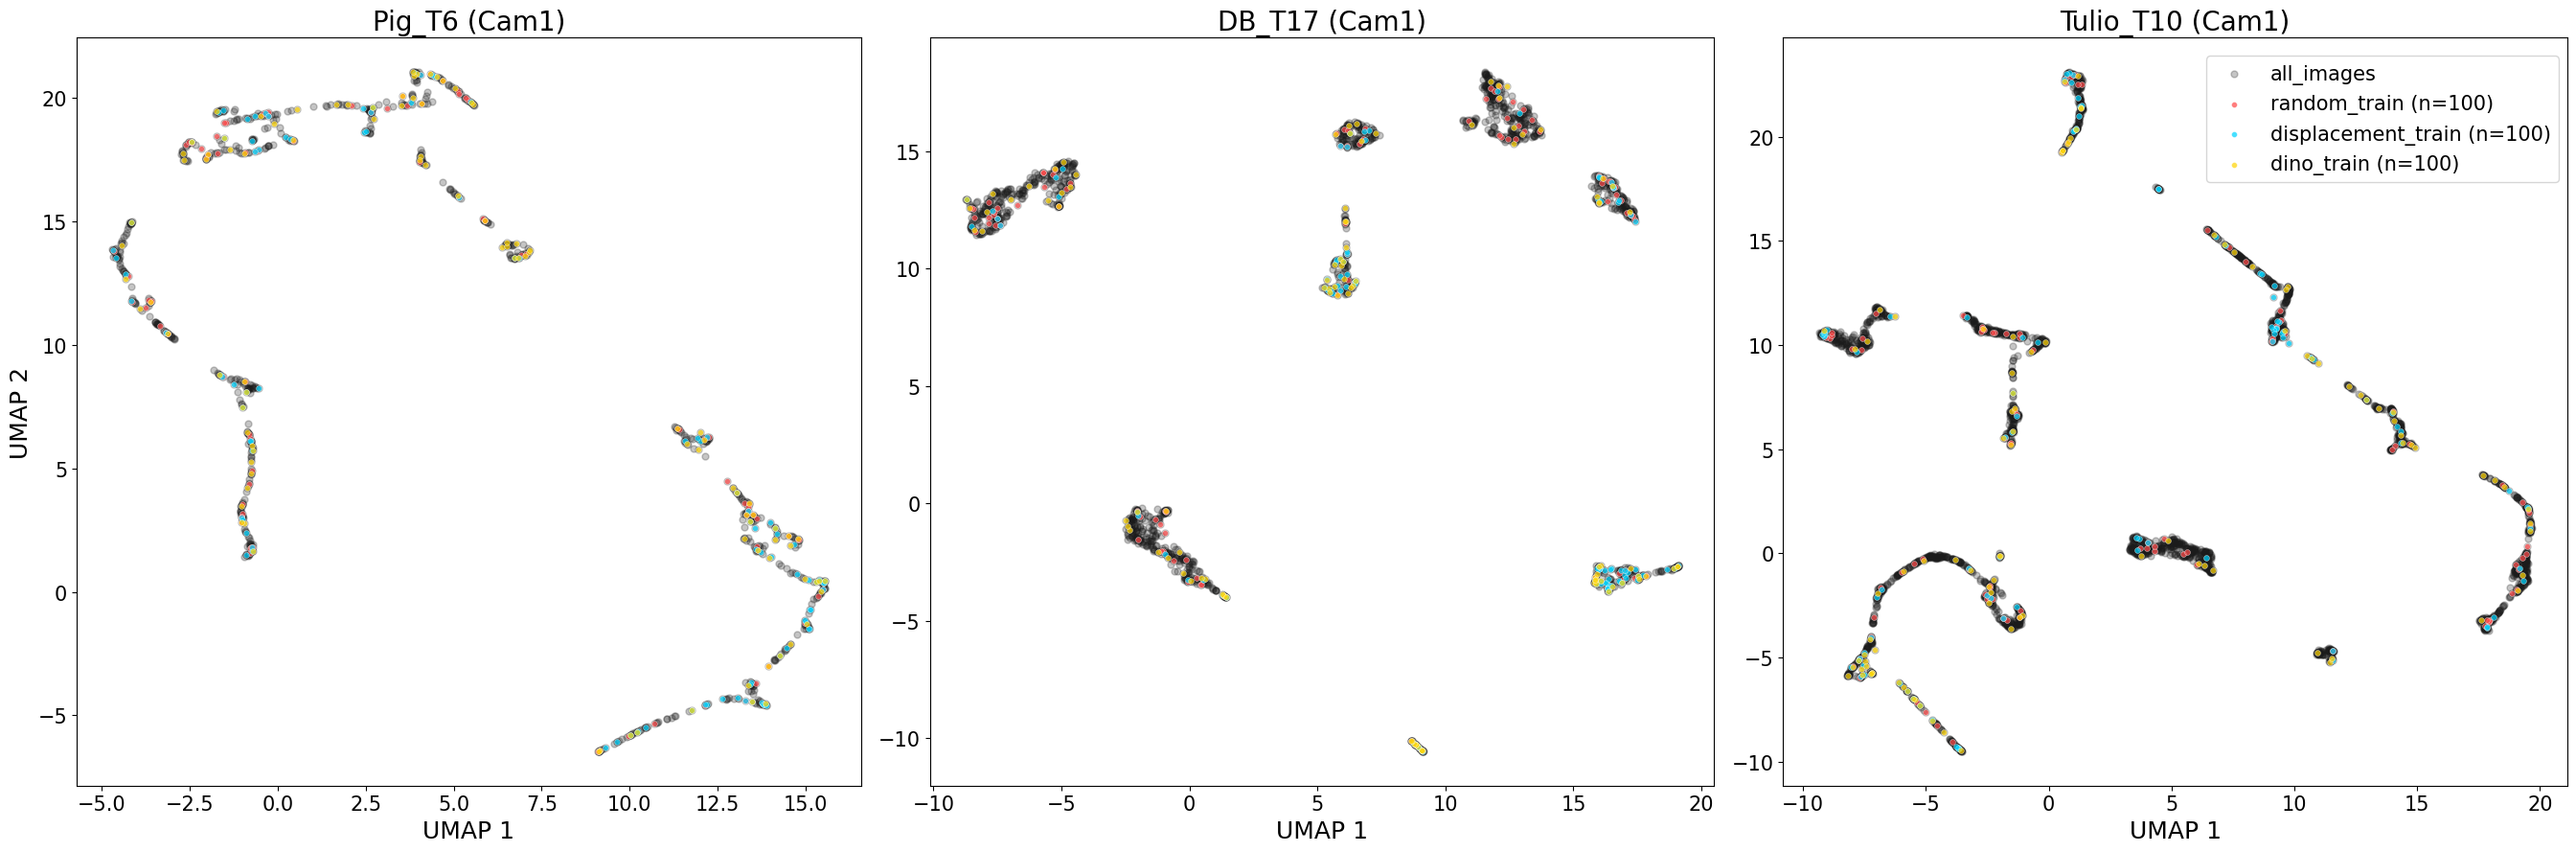

In [23]:
import matplotlib.pyplot as plt
import numpy as np


# ============================================================
# COLORS
# ============================================================

overlay_specs = [
    ("random", "#ff4d4d"),
    ("displacement", "#00d4ff"),
    ("dino", "#ffd60a"),
]


# ============================================================
# 1 x N GRID
# ============================================================

n_trials = len(embedding_results)

fig, axes = plt.subplots(
    1,
    n_trials,
    figsize=(9 * n_trials, 9),
    squeeze=False,
)

axes = axes[0]


for ax, result in zip(axes, embedding_results):

    embedding_2d = result["embedding_2d"]
    method_to_indices = result["method_to_indices"]

    # --------------------------------------------------------
    # All images: dark background cloud
    # --------------------------------------------------------

    ax.scatter(
        embedding_2d[:, 0],
        embedding_2d[:, 1],
        s=25,
        alpha=0.25,
        c="#1b1b1b",
        label="all_images",
    )

    # --------------------------------------------------------
    # Training selections
    # --------------------------------------------------------

    for method_name, color in overlay_specs:

        idx = method_to_indices.get(
            method_name,
            np.asarray([], dtype=int)
        )

        if idx.size == 0:
            continue

        ax.scatter(
            embedding_2d[idx, 0],
            embedding_2d[idx, 1],
            s=18,
            alpha=0.72,
            c=color,
            edgecolors="white",
            linewidths=0.35,
            label=(
                f"{method_name}_train "
                f"(n={idx.size})"
            ),
        )

    # --------------------------------------------------------
    # Formatting
    # --------------------------------------------------------

    ax.set_title(
        f"{result['trial']} ({result['camera']})",
        fontsize=20,
    )

    ax.set_xlabel(
        "UMAP 1" if umap is not None else "PC 1",
        fontsize=18,
    )

    ax.set_ylabel(
        "UMAP 2" if umap is not None else "PC 2",
        fontsize=18,
    )

    ax.tick_params(

        labelsize=15
    )

    axes[1].set_ylabel("")
    axes[2].set_ylabel("")

# ============================================================
# ONE SHARED LEGEND
# ============================================================

handles, labels = axes[2].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc="upper right",
    bbox_to_anchor=(0.995, 0.94),
    ncol=1,
    frameon=True,
    fontsize=15,
)



# ============================================================
# FINAL LAYOUT
# ============================================================

plt.tight_layout()
plt.savefig(r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCutExperiments\Figures\All_Trial_Embeddings_Figure.png")
plt.show()

In [6]:

DATA_ROOT = Path(r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCutExperiments\Data")
TRIAL_DIR = DATA_ROOT / TRIAL_FOR_EMBED_VIS

if not TRIAL_DIR.exists():
    raise FileNotFoundError(f"Trial folder not found: {TRIAL_DIR}")

COMPLETE_CAM_DIR = TRIAL_DIR / "CompleteSet" / CAMERA_FOR_EMBED_VIS
TRAIN_CAM_DIR = TRIAL_DIR / "train" / CAMERA_FOR_EMBED_VIS

complete_images = _list_images_sorted(COMPLETE_CAM_DIR)
train_images = _list_images_sorted(TRAIN_CAM_DIR)

if not complete_images:
    raise RuntimeError(f"No complete-set images found in: {COMPLETE_CAM_DIR}")
if not train_images:
    raise RuntimeError(f"No train-set images found in: {TRAIN_CAM_DIR}")

# Compute DINO embeddings for all complete-set images (background cloud)
embeddings = _compute_dino_embeddings(
    complete_images,
    batch_size=DINO_BATCH_SIZE,
    model_name=DINO_MODEL_NAME,
)

if umap is not None:
    reducer = umap.UMAP(
        n_neighbors=UMAP_NEIGHBORS,
        min_dist=UMAP_MIN_DIST,
        metric=UMAP_METRIC,
        random_state=RANDOM_SEED,
    )
    embedding_2d = reducer.fit_transform(embeddings)
else:
    from sklearn.decomposition import PCA

    pca = PCA(n_components=2, random_state=RANDOM_SEED)
    embedding_2d = pca.fit_transform(embeddings)

# Build index sets for overlays by mapping selected train image names into complete-set positions.
complete_name_to_idx = {p.name: i for i, p in enumerate(complete_images)}
train_name_list = [p.name for p in train_images]

method_to_indices = {}
for method in ("random", "displacement", "dino"):
    train_local_indices = _read_selected_indices(TRIAL_DIR, method, NFRAMES_FOR_METHOD_METADATA)
    selected_names = [train_name_list[i] for i in train_local_indices if 0 <= i < len(train_name_list)]
    method_to_indices[method] = np.asarray([complete_name_to_idx[name] for name in selected_names if name in complete_name_to_idx], dtype=int)

test_names = _load_split_test_filenames(TRIAL_DIR, CAMERA_FOR_EMBED_VIS)
test_indices = np.asarray([complete_name_to_idx[name] for name in test_names if name in complete_name_to_idx], dtype=int)

print(
    {
        "trial": TRIAL_FOR_EMBED_VIS,
        "camera": CAMERA_FOR_EMBED_VIS,
        "n_all_images": len(complete_images),
        "n_random": int(method_to_indices["random"].size),
        "n_displacement": int(method_to_indices["displacement"].size),
        "n_dino": int(method_to_indices["dino"].size),
        "n_test": int(test_indices.size),
        "reducer": "UMAP" if umap is not None else "PCA (fallback)",
    }
)

Using cache found in C:\Users\Salle-Cineradio/.cache\torch\hub\facebookresearch_dinov2_main
C:\Users\Salle-Cineradio/.cache\torch\hub\facebookresearch_dinov2_main\dinov2\layers\swiglu_ffn.py:51: UserWarning: xFormers is not available (SwiGLU)
  warnings.warn("xFormers is not available (SwiGLU)")
C:\Users\Salle-Cineradio/.cache\torch\hub\facebookresearch_dinov2_main\dinov2\layers\attention.py:33: UserWarning: xFormers is not available (Attention)
  warnings.warn("xFormers is not available (Attention)")
C:\Users\Salle-Cineradio/.cache\torch\hub\facebookresearch_dinov2_main\dinov2\layers\block.py:40: UserWarning: xFormers is not available (Block)
  warnings.warn("xFormers is not available (Block)")
c:\Users\Salle-Cineradio\Documents\miniconda\envs\DEEPLABCUT\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


{'trial': 'Pig_T6', 'camera': 'Cam1', 'n_all_images': 880, 'n_random': 50, 'n_displacement': 50, 'n_dino': 50, 'n_test': 300, 'reducer': 'UMAP'}


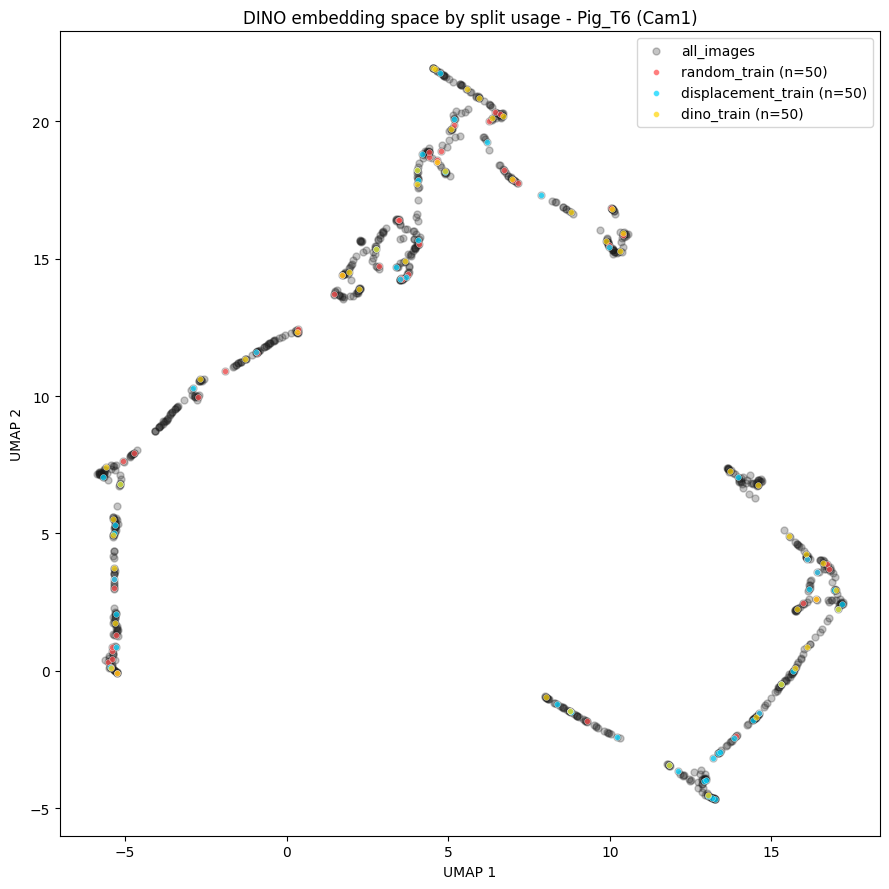

In [7]:
#  scatter overlay: dark background cloud + bright split selections
plt.figure(figsize=(9, 9))

# All images (background)
plt.scatter(
    embedding_2d[:, 0],
    embedding_2d[:, 1],
    s=25,
    alpha=0.25,
    c="#1b1b1b",
    label="all_images",
)

overlay_specs = [
    ("random", "#ff4d4d"),
    ("displacement", "#00d4ff"),
    ("dino", "#ffd60a"),
]

for method_name, color in overlay_specs:
    idx = method_to_indices.get(method_name, np.asarray([], dtype=int))
    if idx.size == 0:
        continue
    plt.scatter(
        embedding_2d[idx, 0],
        embedding_2d[idx, 1],
        s=18,
        alpha=0.72,
        c=color,
        edgecolors="white",
        linewidths=0.35,
        label=f"{method_name}_train (n={idx.size})",
    )

# if test_indices.size > 0:
#     plt.scatter(
#         embedding_2d[test_indices, 0],
#         embedding_2d[test_indices, 1],
#         s=25,
#         alpha=0.95,
#         c="#39ff14",
#         marker="^",
#         edgecolors="black",
#         linewidths=0.45,
#         label=f"test_split (n={test_indices.size})",
#     )

plt.legend(loc="best", frameon=True)
plt.title(f"DINO embedding space by split usage - {TRIAL_FOR_EMBED_VIS} ({CAMERA_FOR_EMBED_VIS})")
plt.xlabel("UMAP 1" if umap is not None else "PC 1")
plt.ylabel("UMAP 2" if umap is not None else "PC 2")
plt.tight_layout()
plt.show()

### All-Trials Split Embedding Grid

Run this to generate the same split-overlay visualization for every trial in `Data/`.

In [59]:
from sklearn.svm import SVC


In [60]:



def _build_dino_model_once(model_name: str = "dinov2_vits14"):
    device = "cuda" if torch.cuda.is_available() else "cpu"
    model = torch.hub.load("facebookresearch/dinov2", model_name)
    model.eval().to(device)
    transform = transforms.Compose(
        [
            transforms.Resize((224, 224)),
            transforms.ToTensor(),
            transforms.Normalize(mean=(0.5, 0.5, 0.5), std=(0.5, 0.5, 0.5)),
        ]
    )
    return model, transform, device


def _compute_embeddings_with_model(image_paths, model, transform, device, batch_size: int = 32):
    feats = []
    for start in range(0, len(image_paths), int(batch_size)):
        batch_paths = image_paths[start : start + int(batch_size)]
        batch_tensors = []
        for image_path in batch_paths:
            with Image.open(image_path) as image_file:
                batch_tensors.append(transform(image_file.convert("RGB")))
        batch = torch.stack(batch_tensors).to(device)
        with torch.no_grad():
            out = model(batch)
        feats.append(out.detach().cpu())

    emb = torch.cat(feats, dim=0)
    emb = emb / emb.norm(dim=1, keepdim=True).clamp_min(1e-12)
    return emb.numpy()


In [61]:
# Embeddings for one camera
def plot_all_trials_split_embeddings(
    data_root: Path,
    nframes: int = 50,
    camera: str = "Cam1",
    batch_size: int = 32,
):
    trial_dirs = sorted(
        [
            p
            for p in data_root.iterdir()
            if p.is_dir() and (p / "CompleteSet" / camera).exists()
        ]
    )

    if len(trial_dirs) == 0:
        raise RuntimeError(f"No trials found under {data_root} for camera {camera}")

    model, transform, device = _build_dino_model_once(
        model_name=DINO_MODEL_NAME
    )

    all_embeddings = []
    method_indices = {"random": [], "displacement": [], "dino": []}

    start = 0

    for trial_dir in trial_dirs:
        complete_images = _list_images_sorted(trial_dir / "CompleteSet" / camera)
        train_images = _list_images_sorted(trial_dir / "train" / camera)

        if len(complete_images) == 0 or len(train_images) == 0:
            continue

        embeddings = _compute_embeddings_with_model(
            complete_images,
            model=model,
            transform=transform,
            device=device,
            batch_size=batch_size,
        )

        all_embeddings.append(embeddings)

        complete_name_to_idx = {p.name: i for i, p in enumerate(complete_images)}
        train_name_list = [p.name for p in train_images]

        for method in ("random", "displacement", "dino"):
            train_local_indices = _read_selected_indices(
                trial_dir, method, int(nframes)
            )

            selected_names = [
                train_name_list[i]
                for i in train_local_indices
                if 0 <= i < len(train_name_list)
            ]

            global_idx = np.asarray(
                [
                    complete_name_to_idx[name] + start
                    for name in selected_names
                    if name in complete_name_to_idx
                ],
                dtype=int,
            )

            method_indices[method].append(global_idx)

        start += len(embeddings)

    all_embeddings = np.vstack(all_embeddings)

    if umap is not None:
        reducer = umap.UMAP(
            n_neighbors=UMAP_NEIGHBORS,
            min_dist=UMAP_MIN_DIST,
            metric=UMAP_METRIC,
            random_state=RANDOM_SEED,
        )
        embedding_2d = reducer.fit_transform(all_embeddings)
        xlab, ylab = "UMAP 1", "UMAP 2"
    else:
        from sklearn.decomposition import PCA

        pca = PCA(n_components=2, random_state=RANDOM_SEED)
        embedding_2d = pca.fit_transform(all_embeddings)
        xlab, ylab = "PC 1", "PC 2"

    fig, ax = plt.subplots(figsize=(10, 8))

    # Background: every image
    ax.scatter(
        embedding_2d[:, 0],
        embedding_2d[:, 1],
        s=20,
        alpha=0.22,
        c="#1b1b1b",
        label="all_images",
    )

    colors = {
        "random": "#ff4d4d",
        "displacement": "#00d4ff",
        "dino": "#ffd60a",
    }
    i = 1
    for method, color in colors.items():
        if len(method_indices[method]) == 0:
            continue
        alpha = .9/i

        idx = np.concatenate(method_indices[method])

        ax.scatter(
            embedding_2d[idx, 0],
            embedding_2d[idx, 1],
            s=20,
            alpha=alpha,
            c=color,
            # edgecolors="white",
            # linewidths=0.3,
            label=f"{method}",
        )
        i = i + .5

    ax.set_title(
        f"All Trials - Split Usage Embeddings (nframes={nframes}, camera={camera})"
    )
    ax.set_xlabel(xlab)
    ax.set_ylabel(ylab)
    ax.legend()
    plt.tight_layout()
    plt.show()

plot_all_trials_split_embeddings(
    data_root=DATA_ROOT,
    nframes=NFRAMES_FOR_METHOD_METADATA,
    camera="Cam1",
    batch_size=DINO_BATCH_SIZE,
    
)

Using cache found in C:\Users\Salle-Cineradio/.cache\torch\hub\facebookresearch_dinov2_main
C:\Users\Salle-Cineradio/.cache\torch\hub\facebookresearch_dinov2_main\dinov2\layers\swiglu_ffn.py:51: UserWarning: xFormers is not available (SwiGLU)
  warnings.warn("xFormers is not available (SwiGLU)")
C:\Users\Salle-Cineradio/.cache\torch\hub\facebookresearch_dinov2_main\dinov2\layers\attention.py:33: UserWarning: xFormers is not available (Attention)
  warnings.warn("xFormers is not available (Attention)")
C:\Users\Salle-Cineradio/.cache\torch\hub\facebookresearch_dinov2_main\dinov2\layers\block.py:40: UserWarning: xFormers is not available (Block)
  warnings.warn("xFormers is not available (Block)")


NameError: name '_read_selected_indices' is not defined

Using cache found in C:\Users\Salle-Cineradio/.cache\torch\hub\facebookresearch_dinov2_main
c:\Users\Salle-Cineradio\Documents\miniconda\envs\DEEPLABCUT\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


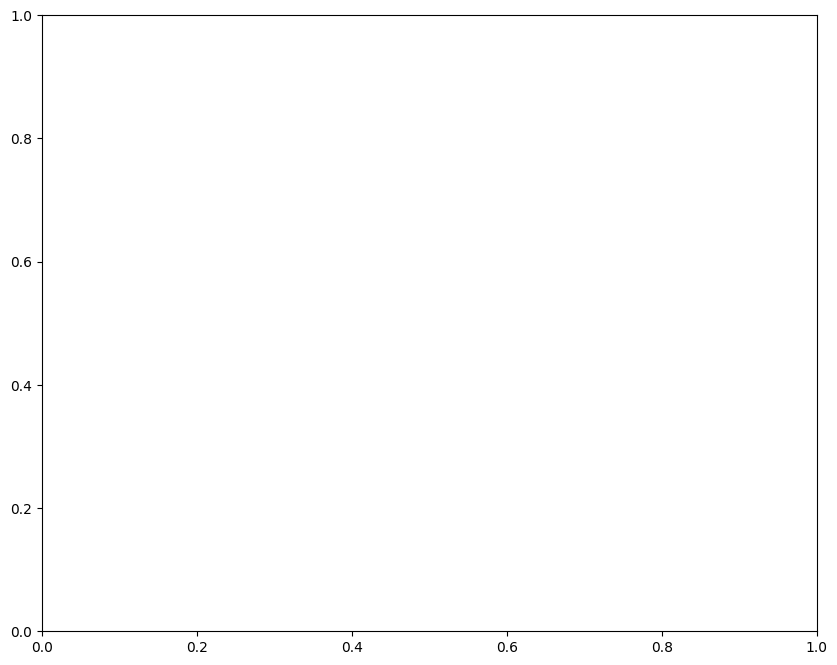

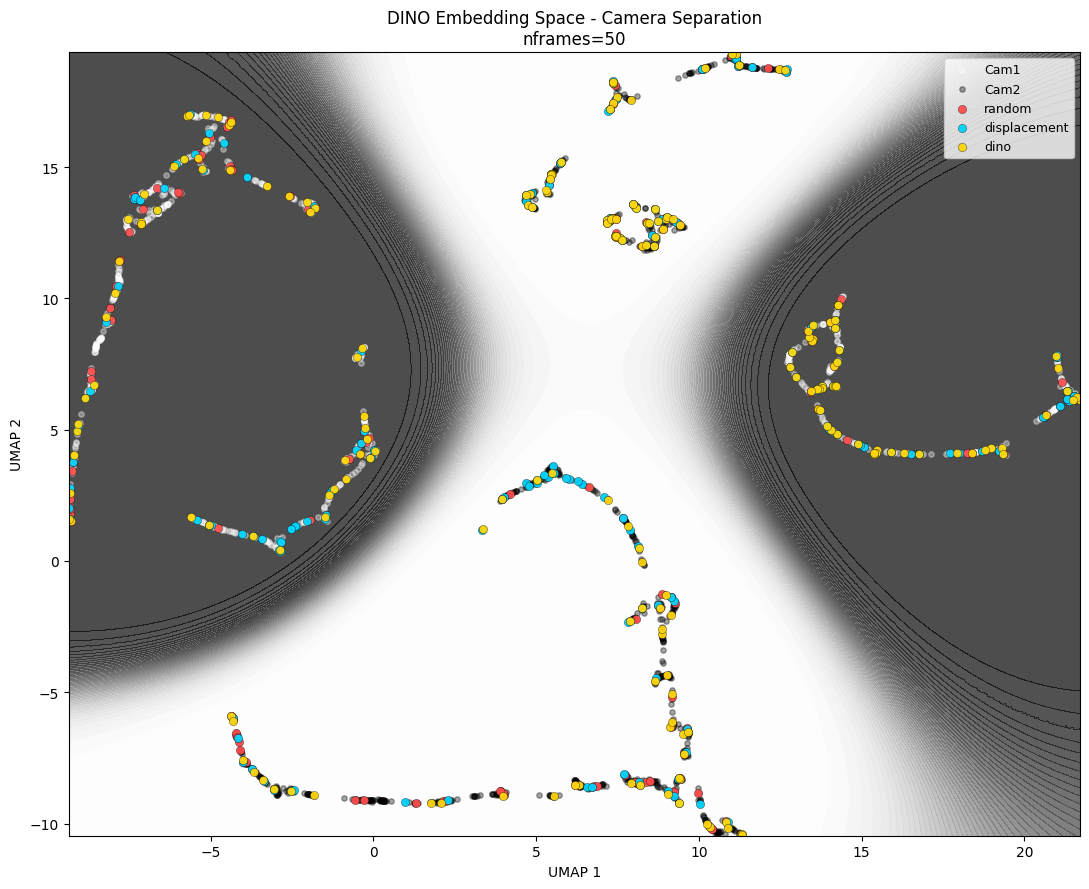

<Figure size 640x480 with 0 Axes>

In [19]:
# Embeddings for both cameras with backdrop
def plot_all_trials_split_embeddings(
    data_root: Path,
    nframes: int = 50,
    cameras=("Cam1", "Cam2"),
    batch_size: int = 32,
):
    trial_dirs = sorted([p for p in data_root.iterdir() if p.is_dir()])

    model, transform, device = _build_dino_model_once(
        model_name=DINO_MODEL_NAME
    )

    all_embeddings = []
    all_cameras = []
    method_indices = {"random": [], "displacement": [], "dino": []}

    start = 0

    for trial_dir in trial_dirs:
        if "evaluation_results" in str(trial_dir):
            continue
        for camera in cameras:

            complete_images = _list_images_sorted(
                trial_dir / "CompleteSet" / camera
            )
            train_images = _list_images_sorted(
                trial_dir / "train" / camera
            )

            if len(complete_images) == 0 or len(train_images) == 0:
                continue

            embeddings = _compute_embeddings_with_model(
                complete_images,
                model=model,
                transform=transform,
                device=device,
                batch_size=batch_size,
            )

            all_embeddings.append(embeddings)
            all_cameras.extend([camera] * len(embeddings))

            complete_name_to_idx = {
                p.name: i for i, p in enumerate(complete_images)
            }
            train_name_list = [p.name for p in train_images]

            for method in method_indices.keys():

                train_local_indices = _read_selected_indices(
                    trial_dir, method, int(nframes)
                )

                selected_names = [
                    train_name_list[i]
                    for i in train_local_indices
                    if 0 <= i < len(train_name_list)
                ]

                global_idx = np.asarray(
                    [
                        complete_name_to_idx[name] + start
                        for name in selected_names
                        if name in complete_name_to_idx
                    ],
                    dtype=int,
                )

                method_indices[method].append(global_idx)

            start += len(embeddings)

    all_embeddings = np.vstack(all_embeddings)
    all_cameras = np.asarray(all_cameras)


    # dimensionality reduction
    if umap is not None:
        reducer = umap.UMAP(
            n_neighbors=UMAP_NEIGHBORS,
            min_dist=UMAP_MIN_DIST,
            metric=UMAP_METRIC,
            random_state=RANDOM_SEED,
        )
        embedding_2d = reducer.fit_transform(all_embeddings)
        xlab, ylab = "UMAP 1", "UMAP 2"

    else:
        from sklearn.decomposition import PCA

        embedding_2d = PCA(
            n_components=2,
            random_state=RANDOM_SEED
        ).fit_transform(all_embeddings)

        xlab, ylab = "PC 1", "PC 2"


    fig, ax = plt.subplots(figsize=(10, 8))


    # Plot cameras separately
    camera_styles = {
        "Cam1": ("#377eb8", "o"),
        "Cam2": ("#e41a1c", "^"),
    }

    for cam, (color, marker) in camera_styles.items():

        idx = np.where(all_cameras == cam)[0]
        
    # ============================
    # Camera separation classifier
    # ============================

    y_cam = (all_cameras == "Cam2").astype(int)

    # cam_clf = SVC(
    #     kernel="linear",
    #     probability=True
    # )
    cam_clf = SVC(
        kernel="rbf",
        gamma="scale",
        C=5,
        probability=True
    )
    cam_clf.fit(
        embedding_2d,
        y_cam
    )


    fig, ax = plt.subplots(
        figsize=(11, 9),
        facecolor="white"
    )


    # ============================
    # Draw camera background
    # ============================

    x_min, x_max = embedding_2d[:,0].min(), embedding_2d[:,0].max()
    y_min, y_max = embedding_2d[:,1].min(), embedding_2d[:,1].max()

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 500),
        np.linspace(y_min, y_max, 500)
    )

    grid = np.c_[xx.ravel(), yy.ravel()]

    cam_probability = cam_clf.predict_proba(grid)[:, 1]
    cam_probability = cam_probability.reshape(xx.shape)

    ax.contourf(
        xx,
        yy,
        cam_probability,
        levels=np.linspace(0,1,50),
        cmap="gray",
        alpha=0.7
    )


    # ============================
    # Plot camera points
    # ============================

    cam1_idx = np.where(all_cameras == "Cam1")[0]
    cam2_idx = np.where(all_cameras == "Cam2")[0]


    ax.scatter(
        embedding_2d[cam1_idx,0],
        embedding_2d[cam1_idx,1],
        s=15,
        c="white",
        alpha=0.35,
        label="Cam1"
    )


    ax.scatter(
        embedding_2d[cam2_idx,0],
        embedding_2d[cam2_idx,1],
        s=15,
        c="black",
        edgecolors="black",
        alpha=0.35,
        label="Cam2"
    )


    # ============================
    # Overlay selected frames
    # ============================

    method_colors = {
        "random": "#ff4d4d",
        "displacement": "#00d4ff",
        "dino": "#ffd60a",
    }


    for method, color in method_colors.items():

        if len(method_indices[method]) == 0:
            continue

        idx = np.concatenate(method_indices[method])

        ax.scatter(
            embedding_2d[idx,0],
            embedding_2d[idx,1],
            s=35,
            c=color,
            edgecolors="black",
            linewidths=0.25,
            alpha=0.95,
            label=method
        )


    ax.set_title(
        f"DINO Embedding Space - Camera Separation\nnframes={nframes}"
    )

    ax.set_xlabel(xlab)
    ax.set_ylabel(ylab)

    ax.legend(
        frameon=True,
        fontsize=9
    )

    plt.tight_layout()
    plt.show()

    ax.set_title(
        f"All Trials - Both Cameras - DINO embeddings (nframes={nframes})"
    )
    ax.set_xlabel(xlab)
    ax.set_ylabel(ylab)
    ax.legend()

    plt.tight_layout()
    plt.show()

plot_all_trials_split_embeddings(
    data_root=DATA_ROOT,
    nframes=NFRAMES_FOR_METHOD_METADATA,
    cameras=("Cam1", "Cam2"),

    batch_size=DINO_BATCH_SIZE,
    # ncols=3,
)

# ------------------------------------------------------------

### Full Suite Training (Single GPU, Trial-Agnostic Timing)

Run the next cell to train the entire generated suite (`random`, `displacement`, `dino` × `nframes` 100/50) on a single GPU.

This writes a run-level manifest with per-job timing (`elapsed_seconds`), which we summarize in the following analysis cell.

In [14]:

# Resolve paths robustly whether notebook is opened at repo root or DeepLabCutExperiments/
def _resolve_training_paths_training() -> tuple[Path, Path]:
    cwd = Path.cwd().resolve()
    # ENSURE: change location based on data
    data_fold = "CombinedTrial"

    direct_script = cwd / "training_sets" / "train_all_models.py"
    direct_manifest = cwd / data_fold / "training_set_build_manifest.csv"
    if direct_script.exists() and direct_manifest.exists():
        return direct_script, direct_manifest

    nested_script = cwd / "DeepLabCutExperiments" / "training_sets" / "train_all_models.py"
    # ENSURE: change location based on data
    data_fold = "CombinedTrial"
    nested_manifest = cwd / "DeepLabCutExperiments" / data_fold / "training_set_build_manifest.csv"
    if nested_script.exists() and nested_manifest.exists():
        return nested_script, nested_manifest

    raise FileNotFoundError(
        "Could not resolve training script/manifest. Expected either "
        "training_sets/train_all_models.py + CombinedTrials/training_set_build_manifest.csv "
        "or DeepLabCutExperiments/training_sets/train_all_models.py + "
        "DeepLabCutExperiments/CombinedTrials/training_set_build_manifest.csv from current working directory."
    )


In [15]:

TRAIN_SCRIPT, TRAINING_SET_BUILD_MANIFEST = _resolve_training_paths_training()
TRAINING_DATA_DIR = TRAINING_SET_BUILD_MANIFEST.parent

# Single-GPU full-suite defaults
EPOCHS = 125
METHODS = ["random", "displacement", "dino"]
NFRAMES = [100, 50]
MAX_WORKERS = 1  # single GPU

# Keep conservative defaults for single GPU stability; tune upward later if VRAM allows.
TRAIN_NETWORK_KWARGS = {
    "batch_size": 16,

}

cmd = [
    sys.executable,
    "-u",  # unbuffered output so notebook shows progress lines live
    str(TRAIN_SCRIPT),
    "--manifest",
    str(TRAINING_SET_BUILD_MANIFEST),
    "--epochs",
    str(EPOCHS),
    "--methods",
    *METHODS,
    "--nframes",
    *[str(v) for v in NFRAMES],
    "--max-workers",
    str(MAX_WORKERS),
    "--train-network-kwargs-json",
    json.dumps(TRAIN_NETWORK_KWARGS),
]

print("Launching training command:")
print(" ".join(shlex.quote(x) for x in cmd))
print("\nExpected progress format:")
print("- [train-job i/N] Bird_Ttrial | nframes=... | method=...")
print("- [epoch-progress] ... [#####-----] epoch/total")
print("- [suite-progress] completed=.../N ok=... error=...")

wall_t0 = time.perf_counter()
# proc = subprocess.run(cmd, check=False)

try:
    proc = subprocess.Popen(
        cmd,
        stdout=subprocess.PIPE,
        stderr=subprocess.STDOUT,
        text=True,
        bufsize=1,
    )
except Exception:
    pass

for line in proc.stdout:
    print(line, end="")

returncode = proc.wait()
wall_elapsed = time.perf_counter() - wall_t0

print(f"\nTraining process return code: {proc.returncode}")
print(f"Wall-clock elapsed: {wall_elapsed/3600:.2f} hours")

run_manifests = sorted(
    TRAINING_DATA_DIR.glob("training_run_manifest_*.csv"),
    key=lambda p: p.stat().st_mtime,
)
LATEST_TRAINING_RUN_MANIFEST = run_manifests[-1] if run_manifests else None
print("Latest run manifest:", LATEST_TRAINING_RUN_MANIFEST)

Launching training command:
'c:\Users\Salle-Cineradio\Documents\miniconda\envs\DEEPLABCUT\python.exe' -u 'C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCutExperiments\training_sets\train_all_models.py' --manifest 'C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCutExperiments\CombinedTrial\training_set_build_manifest.csv' --epochs 125 --methods random displacement dino --nframes 100 50 --max-workers 1 --train-network-kwargs-json '{"batch_size": 16}'

Expected progress format:
- [train-job i/N] Bird_Ttrial | nframes=... | method=...
- [epoch-progress] ... [#####-----] epoch/total
- [suite-progress] completed=.../N ok=... error=...
Loaded 24 training jobs
Applying bird bodypart sync to all target configs before training...
Loading DLC 3.0.0rc13...
DLC loaded in light mode; you cannot use any GUI (labeling, relabeling and standalone GUI)
bird                                                                                 

In [9]:
# Full-suite runner scoped to one trial: DB_T16


TRAIN_SCRIPT, TRAINING_SET_BUILD_MANIFEST = _resolve_training_paths()
TRAINING_DATA_DIR = TRAINING_SET_BUILD_MANIFEST.parent

# Target only one trial
TARGET_BIRD = "DavidBowie"   # DB
TARGET_TRIAL_NUM = 16
EPOCHS = 125
METHODS = ["random", "displacement", "dino"]
NFRAMES = [100, 50]
MAX_WORKERS = 1

TRAIN_NETWORK_KWARGS = {
    "batch_size": 12,
}

manifest_df = pd.read_csv(TRAINING_SET_BUILD_MANIFEST)
required_cols = {"bird", "trial_num"}
missing = required_cols - set(manifest_df.columns)
if missing:
    raise ValueError(f"Manifest missing required columns: {sorted(missing)}")

trial_mask = (
    manifest_df["bird"].astype(str).str.strip().str.lower().eq(TARGET_BIRD.lower())
    & pd.to_numeric(manifest_df["trial_num"], errors="coerce").eq(int(TARGET_TRIAL_NUM))
)
trial_manifest_df = manifest_df.loc[trial_mask].copy()

if trial_manifest_df.empty:
    raise RuntimeError(
        f"No manifest rows found for {TARGET_BIRD}_T{TARGET_TRIAL_NUM} in {TRAINING_SET_BUILD_MANIFEST}"
    )

trial_manifest_path = TRAINING_DATA_DIR / f"training_set_build_manifest_{TARGET_BIRD}_T{TARGET_TRIAL_NUM}.csv"
trial_manifest_df.to_csv(trial_manifest_path, index=False)

print(f"Filtered rows: {len(trial_manifest_df)}")
print(f"Trial-only manifest: {trial_manifest_path}")

cmd = [
    sys.executable,
    "-u",
    str(TRAIN_SCRIPT),
    "--manifest",
    str(trial_manifest_path),
    "--epochs",
    str(EPOCHS),
    "--methods",
    *METHODS,
    "--nframes",
    *[str(v) for v in NFRAMES],
    "--max-workers",
    str(MAX_WORKERS),
    "--train-network-kwargs-json",
    json.dumps(TRAIN_NETWORK_KWARGS),
]

print("Launching training command:")
print(" ".join(shlex.quote(x) for x in cmd))

wall_t0 = time.perf_counter()
proc = subprocess.run(cmd, check=False)
wall_elapsed = time.perf_counter() - wall_t0

print(f"\nTraining process return code: {proc.returncode}")
print(f"Wall-clock elapsed: {wall_elapsed/3600:.2f} hours")

run_manifests = sorted(
    TRAINING_DATA_DIR.glob("training_run_manifest_*.csv"),
    key=lambda p: p.stat().st_mtime,
    reverse=True,
)[:5]

print("\nMost recent run manifests:")
for manifest_path in run_manifests:
    print("-", manifest_path)

Filtered rows: 6
Trial-only manifest: C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCutExperiments\Data\training_set_build_manifest_DavidBowie_T16.csv
Launching training command:
'c:\Users\Salle-Cineradio\Documents\miniconda\envs\DEEPLABCUT\python.exe' -u 'C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCutExperiments\training_sets\train_all_models.py' --manifest 'C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCutExperiments\Data\training_set_build_manifest_DavidBowie_T16.csv' --epochs 125 --methods random displacement dino --nframes 100 50 --max-workers 1 --train-network-kwargs-json '{"batch_size": 12}'

Training process return code: 0
Wall-clock elapsed: 1.55 hours

Most recent run manifests:
- C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCutExperiments\Data\training_run_manifest_20260715_120731.csv


### Trial-Agnostic Summary Across 6 Model Dimensions

This summarizes timing and status pooled across trials by `(nframes, method)`:
- `nframes`: 100 or 50
- `method`: `random`, `displacement`, `dino`

Together these define the 6 model dimensions you asked to compare.

In [48]:
pd.read_csv(r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCutExperiments\Data\ModelBuilds.csv")

,Unnamed: 0,bird,train_trial,method,nframes
0,0,DavidBowie,15,"['dino', 'displacement', 'random']","[50, 100]"
1,1,DavidBowie,16,"['dino', 'displacement', 'random']","[50, 100]"
2,2,DavidBowie,17,"['dino', 'displacement', 'random']","[50, 100]"
3,3,DavidBowie,1516,"['dino', 'displacement', 'random']","[50, 100]"
4,4,DavidBowie,1517,"['dino', 'displacement', 'random']","[50, 100]"
5,5,DavidBowie,1617,"['dino', 'displacement', 'random']","[50, 100]"
6,6,Pig,1,"['dino', 'displacement', 'random']","[50, 100]"
7,7,Pig,6,"['dino', 'displacement', 'random']","[50, 100]"
8,8,Tulio,5,"['dino', 'displacement', 'random']","[50, 100]"
9,9,Tulio,6,"['dino', 'displacement', 'random']","[50, 100]"


In [50]:
pd.read_csv(r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCutExperiments\Data\ModelBuilds.csv").iloc[:, 1:]

,bird,train_trial,method,nframes
0,DavidBowie,15,"['dino', 'displacement', 'random']","[50, 100]"
1,DavidBowie,16,"['dino', 'displacement', 'random']","[50, 100]"
2,DavidBowie,17,"['dino', 'displacement', 'random']","[50, 100]"
3,DavidBowie,1516,"['dino', 'displacement', 'random']","[50, 100]"
4,DavidBowie,1517,"['dino', 'displacement', 'random']","[50, 100]"
5,DavidBowie,1617,"['dino', 'displacement', 'random']","[50, 100]"
6,Pig,1,"['dino', 'displacement', 'random']","[50, 100]"
7,Pig,6,"['dino', 'displacement', 'random']","[50, 100]"
8,Tulio,5,"['dino', 'displacement', 'random']","[50, 100]"
9,Tulio,6,"['dino', 'displacement', 'random']","[50, 100]"


In [33]:


if "LATEST_TRAINING_RUN_MANIFEST" not in globals() or LATEST_TRAINING_RUN_MANIFEST is None:
    data_dir = Path("Data") if Path("Data").exists() else Path("DeepLabCutExperiments") / "Data"
    manifests = sorted(data_dir.glob("training_run_manifest_*.csv"), key=lambda p: p.stat().st_mtime)
    if not manifests:
        raise FileNotFoundError("No training_run_manifest_*.csv found. Run the training cell first.")
    LATEST_TRAINING_RUN_MANIFEST = manifests[-1]

print("Using manifest:", LATEST_TRAINING_RUN_MANIFEST)
run_df = pd.read_csv(LATEST_TRAINING_RUN_MANIFEST)

required = {"bird", "trial_num", "method", "nframes", "status", "elapsed_seconds"}
missing = required - set(run_df.columns)
if missing:
    raise ValueError(f"Manifest missing required columns: {sorted(missing)}")

run_df = run_df.copy()
run_df["elapsed_seconds"] = pd.to_numeric(run_df["elapsed_seconds"], errors="coerce")
run_df["elapsed_minutes"] = run_df["elapsed_seconds"] / 60.0
run_df["elapsed_hours"] = run_df["elapsed_seconds"] / 3600.0
run_df["method"] = run_df["method"].astype(str).str.lower().str.strip()
run_df["trial_key"] = run_df["bird"].astype(str) + "_T" + run_df["trial_num"].astype(int).astype(str)
run_df["is_ok"] = run_df["status"].astype(str).str.lower().eq("ok")

trial_agnostic_summary = (
    run_df.groupby(["nframes", "method"], dropna=False)
    .agg(
        n_jobs=("status", "size"),
        n_ok=("is_ok", "sum"),
        success_rate=("is_ok", "mean"),
        mean_minutes=("elapsed_minutes", "mean"),
        median_minutes=("elapsed_minutes", "median"),
        std_minutes=("elapsed_minutes", "std"),
        min_minutes=("elapsed_minutes", "min"),
        max_minutes=("elapsed_minutes", "max"),
    )
    .reset_index()
    .sort_values(["nframes", "method"])
)
trial_agnostic_summary["success_rate"] = (100.0 * trial_agnostic_summary["success_rate"]).round(1)

print("\nTrial-agnostic (6-dimension) timing summary:")
display(trial_agnostic_summary)

# Keep a trial-level table available for later variance analyses.
trial_level_summary = (
    run_df.groupby(["trial_key", "nframes", "method"], dropna=False)
    .agg(
        n_jobs=("status", "size"),
        n_ok=("is_ok", "sum"),
        mean_minutes=("elapsed_minutes", "mean"),
        median_minutes=("elapsed_minutes", "median"),
    )
    .reset_index()
    .sort_values(["trial_key", "nframes", "method"])
)

summary_out = Path(LATEST_TRAINING_RUN_MANIFEST).with_name(
    Path(LATEST_TRAINING_RUN_MANIFEST).stem + "_trial_agnostic_summary.csv"
)
trial_agnostic_summary.to_csv(summary_out, index=False)
print("Saved trial-agnostic summary:", summary_out)

Using manifest: C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCutExperiments\DataPig\training_run_manifest_20260803_210616.csv

Trial-agnostic (6-dimension) timing summary:


,nframes,method,n_jobs,n_ok,success_rate,mean_minutes,median_minutes,std_minutes,min_minutes,max_minutes
0,50,dino,1,1,100.0,9.974507,9.974507,NaN,9.974507,9.974507
1,50,displacement,1,1,100.0,9.167622,9.167622,NaN,9.167622,9.167622
2,50,random,1,1,100.0,9.260084,9.260084,NaN,9.260084,9.260084
3,100,dino,1,1,100.0,18.444894,18.444894,NaN,18.444894,18.444894
4,100,displacement,1,1,100.0,18.232252,18.232252,NaN,18.232252,18.232252
5,100,random,1,1,100.0,21.381632,21.381632,NaN,21.381632,21.381632


Saved trial-agnostic summary: C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCutExperiments\DataPig\training_run_manifest_20260803_210616_trial_agnostic_summary.csv


In [18]:
training_manifest_df = pd.read_csv(TRAINING_SET_BUILD_MANIFEST)

In [20]:
training_manifest_full = pd.read_csv(r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCutExperiments\Data\training_set_build_manifest.csv")

training_manifest_full_comb = pd.concat([training_manifest_full, training_manifest_df])

training_manifest_full_comb.to_csv(r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCutExperiments\Data\training_set_build_manifest.csv")

In [4]:
# ============================
# Plot 1: Mean loss by model type
# ============================
manifest_df = pd.read_csv(r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCutExperiments\Data\split_manifest.csv")


curves = defaultdict(list)
steps_dict = {}

for _, row in manifest_df.iterrows():

    if row["skipped"]:
        continue

    trial_path = Path(row["trial_path"])

    stats_files = list(trial_path.rglob("learning_stats.csv"))

    if len(stats_files) == 0:
        print(f"No learning stats: {trial_path}")
        continue

    for stats_path in stats_files:

        stats = pd.read_csv(stats_path)

        # model type from folder name
        # e.g. displacement_train
        model_type = stats_path.parts[
            stats_path.parts.index("Data") + 2
        ]

        # nframes from path
        match = re.search(
            r"nframes_(\d+)",
            str(stats_path)
        )

        if match is None:
            print(f"No nframes found: {stats_path}")
            continue

        nframes = int(match.group(1))

        key = (model_type, nframes)

        curves[key].append(
            stats["losses/train.total_loss"].values
        )

        steps_dict[key] = stats["step"].values

('dino_train', 50) 12
('dino_train', 100) 12
('displacement_train', 50) 12
('displacement_train', 100) 12
('random_train', 50) 12
('random_train', 100) 12


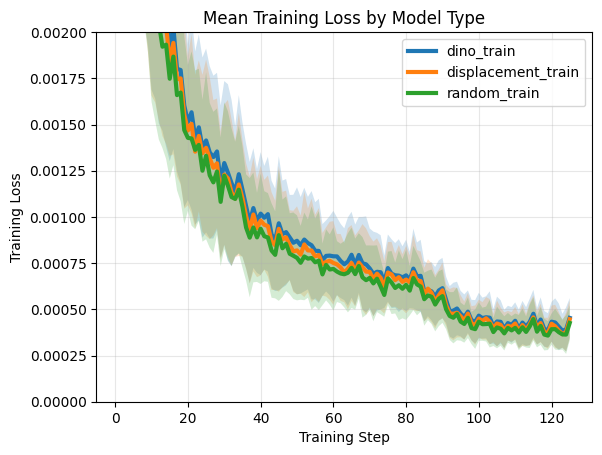

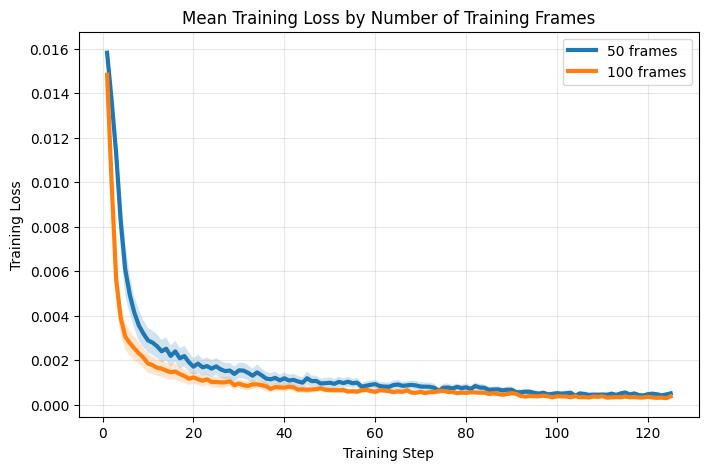

In [5]:

model_curves = defaultdict(list)
model_steps = {}

for (model_type, nframes), runs in curves.items():

    model_curves[model_type].extend(runs)
    model_steps[model_type] = steps_dict[(model_type, nframes)]
for key in sorted(curves):
    print(key, len(curves[key]))

for model_type, runs in model_curves.items():

    min_len = min(len(r) for r in runs)
    runs = np.vstack([r[:min_len] for r in runs])

    mean_loss = runs.mean(axis=0)
    std_loss = runs.std(axis=0)

    steps = model_steps[model_type][:min_len]

    plt.plot(
        steps,
        mean_loss,
        linewidth=3,
        label=model_type,
    )

    plt.fill_between(
        steps,
        mean_loss - std_loss,
        mean_loss + std_loss,
        alpha=0.2,
    )
plt.ylim(0,.002)
plt.xlabel("Training Step")
plt.ylabel("Training Loss")
plt.title("Mean Training Loss by Model Type")
plt.grid(alpha=0.3)
plt.legend()
plt.show()


# ============================
# Plot 2: Mean loss by nframes
# ============================

plt.figure(figsize=(8,5))

frame_curves = defaultdict(list)
frame_steps = {}

for (model_type, nframes), runs in curves.items():

    frame_curves[nframes].extend(runs)
    frame_steps[nframes] = steps_dict[(model_type, nframes)]



for nframes, runs in sorted(frame_curves.items()):

    min_len = min(len(r) for r in runs)
    runs = np.vstack([r[:min_len] for r in runs])

    mean_loss = runs.mean(axis=0)
    std_loss = runs.std(axis=0)

    steps = frame_steps[nframes][:min_len]

    plt.plot(
        steps,
        mean_loss,
        linewidth=3,
        label=f"{nframes} frames",
    )

    plt.fill_between(
        steps,
        mean_loss - std_loss,
        mean_loss + std_loss,
        alpha=0.2,
    )

plt.xlabel("Training Step")
plt.ylabel("Training Loss")
plt.title("Mean Training Loss by Number of Training Frames")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

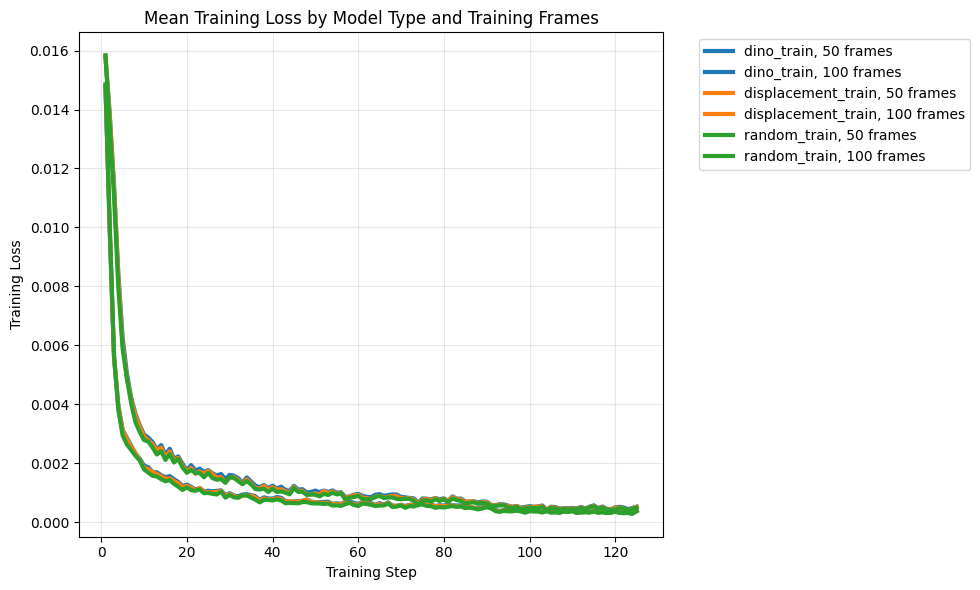

In [6]:

# manifest_df is your dataframe
manifest_df = pd.read_csv(r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCutExperiments\Data\split_manifest.csv")
curves = defaultdict(list)
steps_dict = {}

for _, row in manifest_df.iterrows():

    if row["skipped"]:
        continue

    trial_path = Path(row["trial_path"])

    # Find learning_stats.csv
    stats_files = list(trial_path.rglob("learning_stats.csv"))

    if not stats_files:
        print(f"No stats for {row['trial_name']}")
        continue

    for stats_path in stats_files:

        stats = pd.read_csv(stats_path)

        # Extract model type from path
        # e.g. displacement_train, dino_train, random_train
        model_type = stats_path.parts[
            stats_path.parts.index("Data") + 2
        ]

        # Extract nframes_50, nframes_100, etc.
        nframes_match = re.search(
            r"nframes_(\d+)",
            str(stats_path)
        )

        if nframes_match is None:
            continue

        nframes = int(nframes_match.group(1))

        key = (model_type, nframes)

        curves[key].append(
            stats["losses/train.total_loss"].to_numpy()
        )

        steps_dict[key] = stats["step"].to_numpy()


# Plot means
plt.figure(figsize=(10,6))

colors = {
    "displacement_train": "tab:orange",
    "dino_train": "tab:blue",
    "random_train": "tab:green",
}

for (model_type, nframes), runs in sorted(curves.items()):

    min_len = min(len(r) for r in runs)

    runs = np.vstack(
        [r[:min_len] for r in runs]
    )

    mean_loss = runs.mean(axis=0)

    steps = steps_dict[(model_type, nframes)][:min_len]

    plt.plot(
        steps,
        mean_loss,
        linewidth=3,
        color=colors.get(model_type, None),
        label=f"{model_type}, {nframes} frames",
    )


plt.xlabel("Training Step")
plt.ylabel("Training Loss")
plt.title("Mean Training Loss by Model Type and Training Frames")
plt.grid(alpha=0.3)

plt.legend(
    bbox_to_anchor=(1.05,1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

### ----------------------------------------------------------------------------------------------

### Blob-Detect Final Correction Experiment

Run baseline + blob-detect corrected predictions for all within/across evaluations.

- Writes corrected prediction files as `*-blobDetect.csv`
- Saves score + comparison CSVs under `evaluation_results`
- Shows side-by-side metric comparison for:
  - RMSE
  - Percent points within threshold
  - Percent frames with all points within threshold
  - Mean number of points within threshold per frame

In [1]:
from pathlib import Path

# Root directory containing all experiments
root = Path(r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCutExperiments\CombinedTrial")

for config_file in root.rglob("config.yaml"):
    print(f"Processing: {config_file}")

    lines = config_file.read_text(encoding="utf-8").splitlines()

    new_lines = []
    in_video_sets = False

    for line in lines:
        stripped = line.lstrip()

        # project_path field
        if stripped.startswith("project_path:"):
            line = line.replace("CombinedTrial", "Data")

        # Detect start of video_sets block
        if stripped.startswith("video_sets:"):
            in_video_sets = True
            new_lines.append(line)
            continue

        # End of video_sets block when a new top-level key begins
        if in_video_sets:
            if line and not line.startswith(" ") and not line.startswith("\t"):
                in_video_sets = False
            else:
                line = line.replace("CombinedTrial", "Data")

        new_lines.append(line)

    config_file.write_text("\n".join(new_lines) + "\n", encoding="utf-8")

# ----------------------------
# Process CSV files
# ----------------------------
for csv_file in root.rglob("*_copy.csv"):
    print(f"Processing CSV: {csv_file}")

    text = csv_file.read_text(encoding="utf-8")
    new_text = text.replace("CombinedTrial", "Data")

    if new_text != text:
        csv_file.write_text(new_text, encoding="utf-8")

print("Done.")


Processing: C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCutExperiments\CombinedTrial\Pig_T4\dino_train\nframes_100\ModelsToTune\Canari-FineTuner-2026-08-07\config.yaml
Processing: C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCutExperiments\CombinedTrial\Pig_T4\dino_train\nframes_50\ModelsToTune\Canari-FineTuner-2026-08-07\config.yaml
Processing: C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCutExperiments\CombinedTrial\Pig_T4\displacement_train\nframes_100\ModelsToTune\Canari-FineTuner-2026-08-07\config.yaml
Processing: C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCutExperiments\CombinedTrial\Pig_T4\displacement_train\nframes_50\ModelsToTune\Canari-FineTuner-2026-08-07\config.yaml
Processing: C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCutExperiments\CombinedTrial\Pig_T4\random_train\nframes_100\ModelsToTune

In [15]:

# -----------------------------
# User settings
# -----------------------------
RUN_ALL_BIRDS = False
BIRD_TO_EVAL = "Pig"  # Used when RUN_ALL_BIRDS = False
THRESHOLD_PX = 3.0
FPS_FOR_STACK_TO_AVI = 500
BATCHSIZE_FOR_INFERENCE = 16
DELETE_INTERMEDIATE_PREDICTIONS = False
FORCE_REBUILD_AVI = False  # Critical: avoids stale AVI length causing frame overrun
REPREDICT = False  # Critical: avoids stale AVI length causing frame overrun

# -----------------------------
# Path resolution for inference
# -----------------------------
def _resolve_paths() -> tuple[Path, Path]:
    cwd = Path.cwd().resolve()

    direct_data = cwd / "Data"
    direct_manifest = direct_data / "training_set_build_manifest.csv"
    if direct_manifest.exists():
        return direct_data, direct_manifest

    nested_data = cwd / "DeepLabCutExperiments" / "Data"
    nested_manifest = nested_data / "training_set_build_manifest.csv"
    if nested_manifest.exists():
        return nested_data, nested_manifest

    raise FileNotFoundError(
        "Could not resolve Data/training_set_build_manifest.csv from cwd. "
        "Open notebook from DeepLabCutExperiments/ or repo root."
    )



In [16]:
DATA_ROOT, BUILD_MANIFEST_PATH = _resolve_paths()
BUILD_MANIFEST_PATH

WindowsPath('C:/Users/Salle-Cineradio/Documents/MachineLearning/BirdSongs-MNHN/Testing/DeepLabCutExperiments/Data/training_set_build_manifest.csv')

In [18]:

DATA_ROOT, BUILD_MANIFEST_PATH = _resolve_paths()

run_all_birds = bool(globals().get("RUN_ALL_BIRDS", False))
run_all_birds = False
# threshold_px = float(globals().get("THRESHOLD_PX", 5.0))
threshold_px = 3
fps_for_inference = int(globals().get("FPS_FOR_STACK_TO_AVI", 500))
batchsize_for_inference = int(globals().get("BATCHSIZE_FOR_INFERENCE", 16))
delete_preds = bool(globals().get("DELETE_INTERMEDIATE_PREDICTIONS", False))
force_rebuild = bool(globals().get("FORCE_REBUILD_AVI", True))
REPREDICT = False    # Only set to true if you really want to repredict on all
if run_all_birds:
    blob_eval_out = evaluate_within_across_blobdetect_all_birds(
        data_root=DATA_ROOT,
        build_manifest_path=BUILD_MANIFEST_PATH,
        birds=None,
        threshold_px=threshold_px,
        fps=fps_for_inference,
        batchsize=batchsize_for_inference,
        delete_intermediate_predictions=delete_preds,
        force_rebuild_avi=force_rebuild,
        repredict_all = REPREDICT,
    )
    blob_scores_df = blob_eval_out["combined_scores_df"]
    blob_compare_df = blob_eval_out["combined_comparison_df"]
else:
    bird_to_eval = str(globals().get("BIRD_TO_EVAL", "Pig"))
    
    blob_eval_out = evaluate_within_across_blobdetect_for_bird(
        bird=bird_to_eval,
        data_root=DATA_ROOT,
        build_manifest_path=BUILD_MANIFEST_PATH,
        threshold_px=threshold_px,
        fps=fps_for_inference,
        batchsize=batchsize_for_inference,
        delete_intermediate_predictions=delete_preds,
        force_rebuild_avi=force_rebuild,
    )
    blob_scores_df = blob_eval_out["scores_df"]
    blob_compare_df = blob_eval_out["comparison_df"]

ok_scores = blob_scores_df[blob_scores_df["status"] == "ok"].copy()

metric_cols = [
    "rmse_px",
    "percent_points_within_threshold",
    "percent_frames_all_points_within_threshold",
    "mean_n_predictions_within_threshold_per_frame",
]

variant_summary = (
    ok_scores.groupby("prediction_variant", as_index=False)[metric_cols]
    .mean(numeric_only=True)
    .sort_values("prediction_variant")
)

print("Average metric summary by prediction variant:")
display(variant_summary)

if blob_compare_df.empty:
    print("No baseline/blobDetect comparison rows were generated.")
else:
    compare_view_cols = [
        "bird",
        "train_trial",
        "eval_trial",
        "method",
        "nframes",
        "rmse_px_baseline",
        "rmse_px_blobDetect",
        "delta_rmse_px_blob_minus_base",
        "percent_points_within_threshold_baseline",
        "percent_points_within_threshold_blobDetect",
        "delta_percent_points_within_threshold_blob_minus_base",
        "percent_frames_all_points_within_threshold_baseline",
        "percent_frames_all_points_within_threshold_blobDetect",
        "delta_percent_frames_all_points_within_threshold_blob_minus_base",
        "mean_n_predictions_within_threshold_per_frame_baseline",
        "mean_n_predictions_within_threshold_per_frame_blobDetect",
        "delta_mean_n_predictions_within_threshold_per_frame_blob_minus_base",
    ]
    compare_view = blob_compare_df[compare_view_cols].sort_values(
        ["bird", "eval_trial", "method", "nframes", "train_trial"],
        kind="mergesort",
    )
    print("Per-run baseline vs blob-detect comparison:")
    display(compare_view)

if not run_all_birds:
    print("Saved combined scores CSV:", blob_eval_out["full_scores_csv"])
    print("Saved comparison CSV:", blob_eval_out["full_comparison_csv"])
    print("Saved point-errors CSV:", blob_eval_out["full_errors_csv"])


pre cleanup
False
Trial: C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCutExperiments\Data\Pig_T1\test
pre analyze
Analyzing Vid: C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCutExperiments\Data\Pig_T1\test\Cam1.avi
Analyzing videos with C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCutExperiments\Data\Pig_T1\dino_train\nframes_50\ModelsToTune\Canari-FineTuner-2026-07-17\dlc-models-pytorch\iteration-0\CanariJul17-trainset95shuffle1\train\snapshot-125.pt
Using scorer: DLC_Resnet50_CanariJul17shuffle1_snapshot_125
Video C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCutExperiments\Data\Pig_T1\test\Cam1.avi already analyzed at C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCutExperiments\Data\Pig_T1\test\dino_n50_TrainT1\Cam1DLC_Resnet50_CanariJul17shuffle1_snapshot_125_full.pickle!
Video C:\Users\Salle-Cineradio\Docu

100%|██████████| 300/300 [00:11<00:00, 27.15it/s]


Saving results in C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCutExperiments\Data\Pig_T1\test\dino_n50_TrainT4\Cam2DLC_Resnet50_CanariAug7shuffle1_snapshot_125.h5 and C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCutExperiments\Data\Pig_T1\test\dino_n50_TrainT4\Cam2DLC_Resnet50_CanariAug7shuffle1_snapshot_125_full.pickle
Starting to analyze C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCutExperiments\Data\Pig_T1\test\Cam1.avi
Video metadata: 
  Overall # of frames:    300
  Duration of video [s]:  0.60
  fps:                    500.0
  resolution:             w=1024, h=1024

Running pose prediction with batch size 16


100%|██████████| 300/300 [00:10<00:00, 27.97it/s]


Saving results in C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCutExperiments\Data\Pig_T1\test\dino_n50_TrainT4\Cam1DLC_Resnet50_CanariAug7shuffle1_snapshot_125.h5 and C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCutExperiments\Data\Pig_T1\test\dino_n50_TrainT4\Cam1DLC_Resnet50_CanariAug7shuffle1_snapshot_125_full.pickle
The videos are analyzed. Now your research can truly start!
You can create labeled videos with 'create_labeled_video'.
If the tracking is not satisfactory for some videos, consider expanding the training set. You can use the function 'extract_outlier_frames' to extract a few representative outlier frames.

post analyze
pre cleanup
False
Trial: C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCutExperiments\Data\Pig_T4\test
pre analyze
Analyzing Vid: C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCutExperiments\Data\Pig_T4\test\Cam1.a

...

Saving results in C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCutExperiments\Data\Pig_T61\test\random_n100_TrainT61\Cam1DLC_Resnet50_CanariAug7shuffle1_snapshot_125.h5 and C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCutExperiments\Data\Pig_T61\test\random_n100_TrainT61\Cam1DLC_Resnet50_CanariAug7shuffle1_snapshot_125_full.pickle
The videos are analyzed. Now your research can truly start!
You can create labeled videos with 'create_labeled_video'.
If the tracking is not satisfactory for some videos, consider expanding the training set. You can use the function 'extract_outlier_frames' to extract a few representative outlier frames.

post analyze
Average metric summary by prediction variant:


,prediction_variant,rmse_px,percent_points_within_threshold,percent_frames_all_points_within_threshold,mean_n_predictions_within_threshold_per_frame
0,baseline,24.353556,84.223765,28.956790,16.844753
1,blobDetect,24.389598,87.553395,48.615741,17.510679


Per-run baseline vs blob-detect comparison:


,bird,train_trial,eval_trial,method,nframes,rmse_px_baseline,rmse_px_blobDetect,delta_rmse_px_blob_minus_base,percent_points_within_threshold_baseline,percent_points_within_threshold_blobDetect,delta_percent_points_within_threshold_blob_minus_base,percent_frames_all_points_within_threshold_baseline,percent_frames_all_points_within_threshold_blobDetect,delta_percent_frames_all_points_within_threshold_blob_minus_base,mean_n_predictions_within_threshold_per_frame_baseline,mean_n_predictions_within_threshold_per_frame_blobDetect,delta_mean_n_predictions_within_threshold_per_frame_blob_minus_base
0,Pig,1,1,dino,50,3.670955,3.617743,-0.053212,98.066667,99.466667,1.400000,68.666667,90.666667,22.000000,19.613333,19.893333,0.280000
36,Pig,4,1,dino,50,48.354243,48.554452,0.200208,62.716667,66.650000,3.933333,0.333333,7.666667,7.333333,12.543333,13.330000,0.786667
72,Pig,6,1,dino,50,21.860326,21.851076,-0.009250,90.983333,97.383333,6.400000,7.666667,67.333333,59.666667,18.196667,19.476667,1.280000
108,Pig,41,1,dino,50,1.904320,1.792996,-0.111324,97.100000,99.450000,2.350000,56.333333,90.666667,34.333333,19.420000,19.890000,0.470000
144,Pig,46,1,dino,50,7.484299,7.344179,-0.140120,91.350000,98.516667,7.166667,17.666667,78.000000,60.333333,18.270000,19.703333,1.433333
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
71,Pig,4,61,random,100,52.010031,52.144490,0.134460,61.050000,63.866667,2.816667,0.333333,3.333333,3.000000,12.210000,12.773333,0.563333
107,Pig,6,61,random,100,11.816291,11.792136,-0.024156,95.233333,97.583333,2.350000,43.333333,67.666667,24.333333,19.046667,19.516667,0.470000
143,Pig,41,61,random,100,23.600579,23.725562,0.124983,87.216667,91.066667,3.850000,28.666667,51.000000,22.333333,17.443333,18.213333,0.770000
179,Pig,46,61,random,100,12.948275,12.876132,-0.072143,93.233333,96.933333,3.700000,33.666667,62.000000,28.333333,18.646667,19.386667,0.740000


Saved combined scores CSV: C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCutExperiments\Data\evaluation_results\Pig_within_across_scores_with_blobDetect_20260810_114232.csv
Saved comparison CSV: C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCutExperiments\Data\evaluation_results\Pig_within_across_blobDetect_comparison_20260810_114232.csv
Saved point-errors CSV: C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCutExperiments\Data\evaluation_results\Pig_within_across_point_errors_with_blobDetect_20260810_114232.csv


In [19]:
dlc_path = Path(r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\Code-Testing\DLCsupport.py")
sys.path.append(str(dlc_path))

from DLCsupport import BIRD_BODYPARTS


# Create a denominator for each row based on the bird
compare_view["n_keypoints"] = (
    compare_view["bird"]
    .map(lambda bird: len(BIRD_BODYPARTS[bird]) * 2)
)

compare_view["mean_percent_preds_win_frame_baseline"] = (
    100
    * compare_view["mean_n_predictions_within_threshold_per_frame_baseline"]
    / compare_view["n_keypoints"]
)

compare_view["mean_percent_preds_win_frame_blobDetect"] = (
    100
    * compare_view["mean_n_predictions_within_threshold_per_frame_blobDetect"]
    / compare_view["n_keypoints"]
)

compare_view["delta_mean_n_predictions_within_threshold_per_frame_blob_minus_base"] = (
    compare_view["mean_percent_preds_win_frame_blobDetect"]
    - compare_view["mean_percent_preds_win_frame_baseline"]
)
compare_view["pair_type"] = np.where(
    compare_view["train_trial"] != compare_view["eval_trial"],
    "across",
    "within"
)

In [8]:
compare_view_copy = compare_view.copy()


In [20]:
compare_view

,bird,train_trial,eval_trial,method,nframes,rmse_px_baseline,rmse_px_blobDetect,delta_rmse_px_blob_minus_base,percent_points_within_threshold_baseline,percent_points_within_threshold_blobDetect,...,percent_frames_all_points_within_threshold_baseline,percent_frames_all_points_within_threshold_blobDetect,delta_percent_frames_all_points_within_threshold_blob_minus_base,mean_n_predictions_within_threshold_per_frame_baseline,mean_n_predictions_within_threshold_per_frame_blobDetect,delta_mean_n_predictions_within_threshold_per_frame_blob_minus_base,n_keypoints,mean_percent_preds_win_frame_baseline,mean_percent_preds_win_frame_blobDetect,pair_type
0,Pig,1,1,dino,50,3.670955,3.617743,-0.053212,98.066667,99.466667,...,68.666667,90.666667,22.000000,19.613333,19.893333,1.400000,20,98.066667,99.466667,within
36,Pig,4,1,dino,50,48.354243,48.554452,0.200208,62.716667,66.650000,...,0.333333,7.666667,7.333333,12.543333,13.330000,3.933333,20,62.716667,66.650000,across
72,Pig,6,1,dino,50,21.860326,21.851076,-0.009250,90.983333,97.383333,...,7.666667,67.333333,59.666667,18.196667,19.476667,6.400000,20,90.983333,97.383333,across
108,Pig,41,1,dino,50,1.904320,1.792996,-0.111324,97.100000,99.450000,...,56.333333,90.666667,34.333333,19.420000,19.890000,2.350000,20,97.100000,99.450000,across
144,Pig,46,1,dino,50,7.484299,7.344179,-0.140120,91.350000,98.516667,...,17.666667,78.000000,60.333333,18.270000,19.703333,7.166667,20,91.350000,98.516667,across
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
71,Pig,4,61,random,100,52.010031,52.144490,0.134460,61.050000,63.866667,...,0.333333,3.333333,3.000000,12.210000,12.773333,2.816667,20,61.050000,63.866667,across
107,Pig,6,61,random,100,11.816291,11.792136,-0.024156,95.233333,97.583333,...,43.333333,67.666667,24.333333,19.046667,19.516667,2.350000,20,95.233333,97.583333,across
143,Pig,41,61,random,100,23.600579,23.725562,0.124983,87.216667,91.066667,...,28.666667,51.000000,22.333333,17.443333,18.213333,3.850000,20,87.216667,91.066667,across
179,Pig,46,61,random,100,12.948275,12.876132,-0.072143,93.233333,96.933333,...,33.666667,62.000000,28.333333,18.646667,19.386667,3.700000,20,93.233333,96.933333,across


In [21]:
compare_view['train_trial'].unique()

array([ 1,  4,  6, 41, 46, 61], dtype=int64)

In [31]:
Model_resutls = pd.read_csv(r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCutExperiments\Data\evaluation_results\ModelResults_Complete.csv").iloc[:, 1:]
Model_resutls = Model_resutls[Model_resutls['bird'] != "Pig"]
Model_results_full = pd.concat([compare_view, Model_resutls])
Model_results_full.to_csv(r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCutExperiments\Data\evaluation_results\ModelResults_Complete_Final.csv")

In [ ]:
# compare_view.to_csv(r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCutExperiments\Data\Results\ModelResults_Complete.csv")

In [49]:

summary = Model_results_full.groupby(
    ['bird', 'train_trial'],
    as_index=False
).agg(
    method=('method', lambda x: list(pd.unique(x))),
    nframes=('nframes', lambda x: list(pd.unique(x)))
)

summary

,bird,train_trial,method,nframes
0,DavidBowie,15,"[dino, displacement, random]","[50, 100]"
1,DavidBowie,16,"[dino, displacement, random]","[50, 100]"
2,DavidBowie,17,"[dino, displacement, random]","[50, 100]"
3,DavidBowie,1516,"[dino, displacement, random]","[50, 100]"
4,DavidBowie,1517,"[dino, displacement, random]","[50, 100]"
5,DavidBowie,1617,"[dino, displacement, random]","[50, 100]"
6,Pig,1,"[dino, displacement, random]","[50, 100]"
7,Pig,4,"[dino, displacement, random]","[50, 100]"
8,Pig,6,"[dino, displacement, random]","[50, 100]"
9,Pig,41,"[dino, displacement, random]","[50, 100]"


In [34]:
summary.to_csv(r'C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCutExperiments\Data\ModelBuilds_Final.csv')

In [35]:

def extract_numbers(x):
    """Return a list of integers from a value."""
    return [int(n) for n in re.findall(r"\d+", str(x))]

def keep_row(row):
    train = row["train_trial"]
    eval_ = row["eval_trial"]

    # Skip if eval_trial has more than 2 numbers
    if int(eval_) > 45:
        return False

    # Skip if train_trial has >2 numbers AND contains any eval_trial number
    train_str = str(train)
    eval_str = str(eval_)
    # if int(train) > 99 and (eval_str in train_str):
    #     return False

    return True




In [41]:
filtered_compare_df = Model_results_full[Model_results_full.apply(keep_row, axis=1)].copy()

filtered_compare_df["CombinedModel"] = (
    filtered_compare_df["train_trial"].apply(lambda x: x > 40)
)
filtered_compare_df["eval_trial"] = filtered_compare_df["eval_trial"].astype(int)
train_str = filtered_compare_df["train_trial"].astype(str)
eval_str = filtered_compare_df["eval_trial"].astype(int).astype(str)


contains = [e in t for t, e in zip(train_str, eval_str)]

filtered_compare_df["pair_type"] = np.where(
    (filtered_compare_df["train_trial"] == filtered_compare_df["eval_trial"]) |
    (
        (filtered_compare_df["train_trial"] >= 40) &
        contains
    ),
    "within",
     "across"
)

C:\Users\Salle-Cineradio\AppData\Local\Temp\ipykernel_18512\4034841659.py:16: FutureWarning: Logical ops (and, or, xor) between Pandas objects and dtype-less sequences (e.g. list, tuple) are deprecated and will raise in a future version. Wrap the object in a Series, Index, or np.array before operating instead.
  (filtered_compare_df["train_trial"] >= 40) &


In [62]:
filtered_compare_df

,bird,train_trial,eval_trial,method,nframes,rmse_px_baseline,rmse_px_blobDetect,delta_rmse_px_blob_minus_base,percent_points_within_threshold_baseline,percent_points_within_threshold_blobDetect,...,delta_percent_frames_all_points_within_threshold_blob_minus_base,mean_n_predictions_within_threshold_per_frame_baseline,mean_n_predictions_within_threshold_per_frame_blobDetect,delta_mean_n_predictions_within_threshold_per_frame_blob_minus_base,n_keypoints,mean_percent_preds_win_frame_baseline,mean_percent_preds_win_frame_blobDetect,pair_type,CombinedModel,Animal
0,Pig,1,1,dino,50,3.670955,3.617743,-0.053212,98.066667,99.466667,...,22.000000,19.613333,19.893333,1.400000,20,98.066667,99.466667,within,False,Pig
36,Pig,4,1,dino,50,48.354243,48.554452,0.200208,62.716667,66.650000,...,7.333333,12.543333,13.330000,3.933333,20,62.716667,66.650000,across,False,Pig
72,Pig,6,1,dino,50,21.860326,21.851076,-0.009250,90.983333,97.383333,...,59.666667,18.196667,19.476667,6.400000,20,90.983333,97.383333,across,False,Pig
108,Pig,41,1,dino,50,1.904320,1.792996,-0.111324,97.100000,99.450000,...,34.333333,19.420000,19.890000,2.350000,20,97.100000,99.450000,within,True,Pig
144,Pig,46,1,dino,50,7.484299,7.344179,-0.140120,91.350000,98.516667,...,60.333333,18.270000,19.703333,7.166667,20,91.350000,98.516667,across,True,Pig
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
343,DavidBowie,16,17,random,100,57.786060,57.722005,-0.064055,52.682540,74.873016,...,0.000000,22.126667,31.446667,22.190476,42,52.682540,74.873016,across,False,Bird
344,DavidBowie,17,17,random,100,2.787722,3.138638,0.350916,98.690476,98.261905,...,-27.333333,41.450000,41.270000,-0.428571,42,98.690476,98.261905,within,False,Bird
345,DavidBowie,1516,17,random,100,9.999229,9.819129,-0.180100,78.492063,94.500000,...,19.000000,32.966667,39.690000,16.007937,42,78.492063,94.500000,across,True,Bird
346,DavidBowie,1517,17,random,100,6.090610,6.284707,0.194097,97.563492,97.166667,...,-20.000000,40.976667,40.810000,-0.396825,42,97.563492,97.166667,within,True,Bird


In [ ]:
# filtered_compare_df.to_csv(r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCutExperiments\Data\Results\SelectedModelResults_Final.csv")

In [44]:
filtered_compare_df['Animal'] = np.where(
    filtered_compare_df['bird'] == "Pig",
    "Pig", "Bird"
)

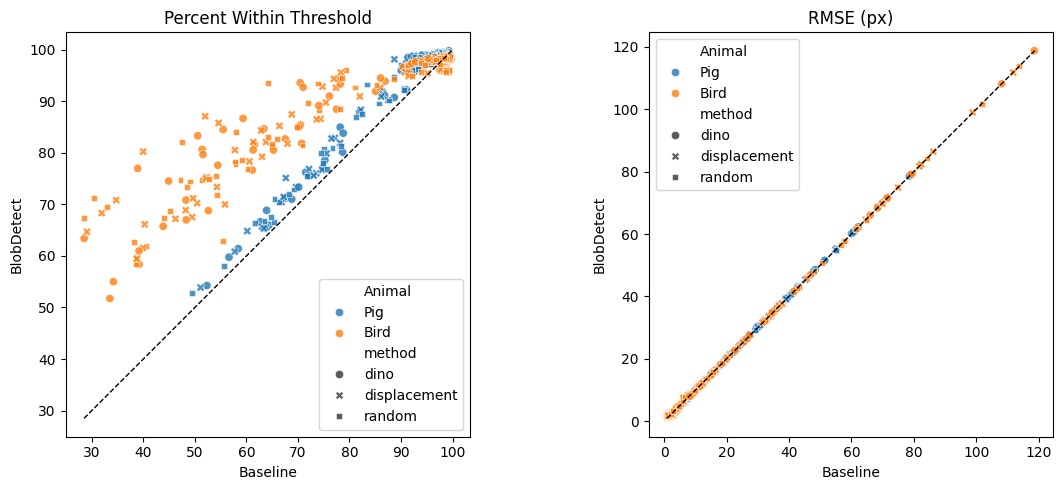

In [45]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

plots = [
    (
        "percent_points_within_threshold_baseline",
        "percent_points_within_threshold_blobDetect",
        "Percent Within Threshold",
    ),
    (
        "rmse_px_baseline",
        "rmse_px_blobDetect",
        "RMSE (px)",
    ),
]
filtered_compare_df["train_trial"] = filtered_compare_df["train_trial"].astype(str)
filtered_compare_df["eval_trial"] = filtered_compare_df["eval_trial"].astype(str)
for ax, (xcol, ycol, title) in zip(axes, plots):


    sns.scatterplot(
        data=filtered_compare_df,
        x=xcol,
        y=ycol,
        hue="Animal",        # optional
        style="method",      # optional
        alpha=0.8,
        ax=ax
    )

    # Identity line
    mn = min(filtered_compare_df[[xcol, ycol]].min())
    mx = max(filtered_compare_df[[xcol, ycol]].max())
    ax.plot([mn, mx], [mn, mx], "k--", lw=1)

    ax.set_xlabel("Baseline")
    ax.set_ylabel("BlobDetect")
    ax.set_title(title)
    ax.set_aspect("equal", adjustable="box")
    

plt.tight_layout()
plt.show()



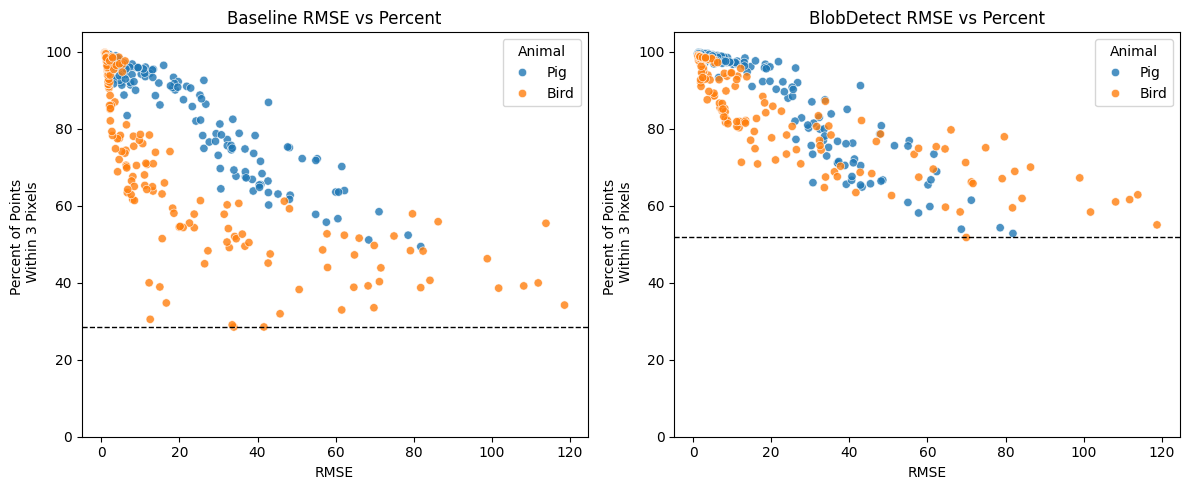

In [46]:

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

plots = [
    (
        "rmse_px_baseline",
        "percent_points_within_threshold_baseline",
        "Baseline RMSE vs Percent",
    ),
    (
        "rmse_px_blobDetect",
        "percent_points_within_threshold_blobDetect",
        "BlobDetect RMSE vs Percent",
    ),
]
filtered_compare_df["train_trial"] = filtered_compare_df["train_trial"].astype(str)
filtered_compare_df["eval_trial"] = filtered_compare_df["eval_trial"].astype(str)
for ax, (xcol, ycol, title) in zip(axes, plots):


    sns.scatterplot(
        data=filtered_compare_df,
        x=xcol,
        y=ycol,
        hue="Animal",      # optional
        alpha=0.8,
        ax=ax
    )
    ax.axhline(filtered_compare_df[ycol].min(), color="k", linestyle="--", lw=1)
    ax.set_xlabel("RMSE")
    ax.set_ylabel("Percent of Points \n Within 3 Pixels")
    ax.set_title(title)
    ax.set_ylim(0, 105)
    # ax.set_aspect("equal", adjustable="box")
    

plt.tight_layout()
plt.show()



                    rmse_px_baseline  rmse_px_blobDetect
rmse_px_baseline            1.000000            0.999902
rmse_px_blobDetect          0.999902            1.000000


Text(0.5, 0, 'BlobDetect RMSE - Baseline RMSE')

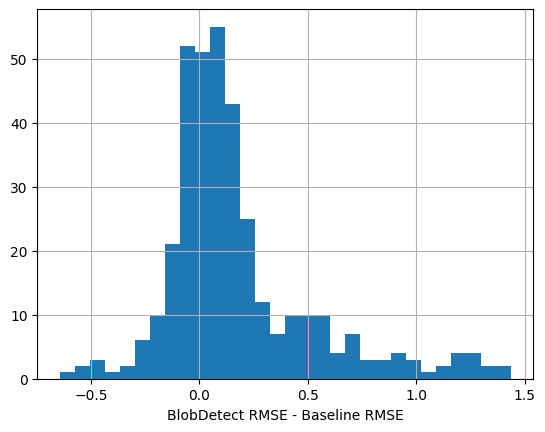

In [47]:
print(filtered_compare_df[
    ["rmse_px_baseline", "rmse_px_blobDetect"]
].corr())

diff = (
    filtered_compare_df["rmse_px_blobDetect"]
    - filtered_compare_df["rmse_px_baseline"]
)

diff.hist(bins=30)
plt.xlabel("BlobDetect RMSE - Baseline RMSE")

### Data Results

#### RMSE data

In [64]:
from itertools import combinations
import pandas as pd

group_cols = ["method", "pair_type", "CombinedModel", "nframes", "Animal"]

agg_metrics = {
    "Baseline_Percent": "percent_points_within_threshold_baseline",
    "BlobDetect_Percent": "percent_points_within_threshold_blobDetect",
    "Baseline_RMSE": "rmse_px_baseline",
    "BlobDetect_RMSE": "rmse_px_blobDetect",
}
# Overall + 1-way + 2-way groupings
groupings = [()]
groupings.extend((c,) for c in group_cols)
groupings.extend(combinations(group_cols, 2))

tables = []

for groups in groupings:

    if len(groups) == 0:
        summary = pd.DataFrame([{
            label: f"{filtered_compare_df[col].mean():.2f} ± {filtered_compare_df[col].std():.2f}"
            for label, col in agg_metrics.items()
        }])
    else:
        summary = (
            filtered_compare_df
            .groupby(list(groups))
            .agg(**{
                label: (col, lambda x: f"{x.mean():.2f} ± {x.std():.2f}")
                for label, col in agg_metrics.items()
            })
            .reset_index()
        )

    # Add missing grouping columns
    for col in group_cols:
        if col not in summary.columns:
            summary[col] = ""

    # Order columns
    summary = summary[group_cols + ["Baseline_Percent", "BlobDetect_Percent", "Baseline_RMSE", "BlobDetect_RMSE"]]

    # Label the aggregation
    summary.insert(
        0,
        "Aggregation",
        "Overall" if len(groups) == 0 else " + ".join(groups)
    )

    tables.append(summary)

final_summary = pd.concat(tables, ignore_index=True)
display(final_summary)

,Aggregation,method,pair_type,CombinedModel,nframes,Animal,Baseline_Percent,BlobDetect_Percent,Baseline_RMSE,BlobDetect_RMSE
0,Overall,,,,,,80.28 ± 19.65,88.00 ± 12.57,19.12 ± 24.00,19.30 ± 23.92
1,method,dino,,,,,81.07 ± 19.39,88.42 ± 12.79,18.88 ± 24.35,19.06 ± 24.26
2,method,displacement,,,,,79.87 ± 19.94,87.78 ± 12.61,18.98 ± 24.13,19.16 ± 24.05
3,method,random,,,,,79.90 ± 19.75,87.78 ± 12.40,19.52 ± 23.72,19.68 ± 23.63
4,pair_type,,across,,,,66.23 ± 16.68,79.49 ± 11.79,32.46 ± 26.02,32.53 ± 26.01
5,pair_type,,within,,,,96.35 ± 4.95,97.72 ± 1.48,3.88 ± 5.13,4.18 ± 4.98
6,CombinedModel,,,False,,,71.35 ± 22.11,82.14 ± 13.93,29.96 ± 27.96,30.09 ± 27.87
7,CombinedModel,,,True,,,89.22 ± 11.16,93.85 ± 7.35,8.29 ± 11.75,8.51 ± 11.68
8,nframes,,,,50,,78.55 ± 19.88,87.35 ± 12.98,20.36 ± 24.81,20.50 ± 24.76
9,nframes,,,,100,,82.02 ± 19.31,88.64 ± 12.14,17.89 ± 23.17,18.10 ± 23.06


In [63]:
from itertools import combinations
from scipy.stats import ttest_rel
import pandas as pd
filtered_compare_df['Animal'] = np.where(
    filtered_compare_df['bird'] == 'Pig',
    'Pig',
    'Bird'
)
group_cols = ["method", "pair_type", "CombinedModel"]

metric_pairs = [
    ("Baseline_Percent", "BlobDetect_Percent",
     "percent_points_within_threshold_baseline",
     "percent_points_within_threshold_blobDetect"),

    ("Baseline_RMSE", "BlobDetect_RMSE",
     "rmse_px_baseline",
     "rmse_px_blobDetect"),
]

groupings = [()]
groupings.extend((c,) for c in group_cols)
groupings.extend(combinations(group_cols, 3))

tables = []

for groups in groupings:

    if len(groups) == 0:
        grouped = [((), filtered_compare_df)]
    else:
        grouped = filtered_compare_df.groupby(list(groups))

    rows = []

    for key, df in grouped:

        row = {}

        if len(groups) > 0:
            if len(groups) == 1:
                row[groups[0]] = key
            else:
                for c, v in zip(groups, key):
                    row[c] = v

        row["N"] = len(df)

        # Summary statistics
        for label_base, label_blob, col_base, col_blob in metric_pairs:

            row[label_base] = f"{df[col_base].mean():.2f} ± {df[col_base].std():.2f}"
            row[label_blob] = f"{df[col_blob].mean():.2f} ± {df[col_blob].std():.2f}"

        # Paired t-tests
        p_percent = ttest_rel(
            df["percent_points_within_threshold_baseline"],
            df["percent_points_within_threshold_blobDetect"],
            nan_policy="omit"
        ).pvalue

        p_rmse = ttest_rel(
            df["rmse_px_baseline"],
            df["rmse_px_blobDetect"],
            nan_policy="omit"
        ).pvalue

        row["Percent p"] = f"{p_percent:.3g}"
        row["RMSE p"] = f"{p_rmse:.3g}"

        rows.append(row)

    summary = pd.DataFrame(rows)

    # Add missing grouping columns
    for col in group_cols:
        if col not in summary.columns:
            summary[col] = ""

    summary.insert(
        0,
        "Aggregation",
        "Overall" if len(groups) == 0 else " + ".join(groups)
    )

    summary = summary[
        ["Aggregation"] + group_cols + [
            "N",
            "Baseline_Percent",
            "BlobDetect_Percent",
            "Percent p",
            "Baseline_RMSE",
            "BlobDetect_RMSE",
            "RMSE p",
        ]
    ]

    tables.append(summary)

final_summary_p = pd.concat(tables, ignore_index=True)
final_summary_p.to_csv(r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCutExperiments\Data\Results\ModelSummary_Stats.csv")
display(final_summary_p)

,Aggregation,method,pair_type,CombinedModel,N,Baseline_Percent,BlobDetect_Percent,Percent p,Baseline_RMSE,BlobDetect_RMSE,RMSE p
0,Overall,,,,360,80.28 ± 19.65,88.00 ± 12.57,1.2e-39,19.12 ± 24.00,19.30 ± 23.92,1.38e-19
1,method,"(dino,)",,,120,81.07 ± 19.39,88.42 ± 12.79,6.6e-14,18.88 ± 24.35,19.06 ± 24.26,9.48e-08
2,method,"(displacement,)",,,120,79.87 ± 19.94,87.78 ± 12.61,2.17e-14,18.98 ± 24.13,19.16 ± 24.05,6.36e-08
3,method,"(random,)",,,120,79.90 ± 19.75,87.78 ± 12.40,2.98e-14,19.52 ± 23.72,19.68 ± 23.63,1.11e-06
4,pair_type,,"(across,)",,192,66.23 ± 16.68,79.49 ± 11.79,3.45e-44,32.46 ± 26.02,32.53 ± 26.01,8.61e-05
5,pair_type,,"(within,)",,168,96.35 ± 4.95,97.72 ± 1.48,1.62e-05,3.88 ± 5.13,4.18 ± 4.98,2.45e-17
6,CombinedModel,,,"(False,)",180,71.35 ± 22.11,82.14 ± 13.93,1.9e-25,29.96 ± 27.96,30.09 ± 27.87,2e-08
7,CombinedModel,,,"(True,)",180,89.22 ± 11.16,93.85 ± 7.35,3.21e-21,8.29 ± 11.75,8.51 ± 11.68,1.09e-12
8,method + pair_type + CombinedModel,dino,across,False,42,61.87 ± 17.31,76.43 ± 12.39,1.18e-10,40.06 ± 26.80,40.11 ± 26.83,0.0173
9,method + pair_type + CombinedModel,dino,across,True,22,77.35 ± 10.28,87.16 ± 9.74,3.74e-07,16.84 ± 19.31,16.94 ± 19.31,0.19


In [65]:
final_summary.to_csv(r'C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCutExperiments\Data\evaluation_results\ModelSummary_Final.csv')

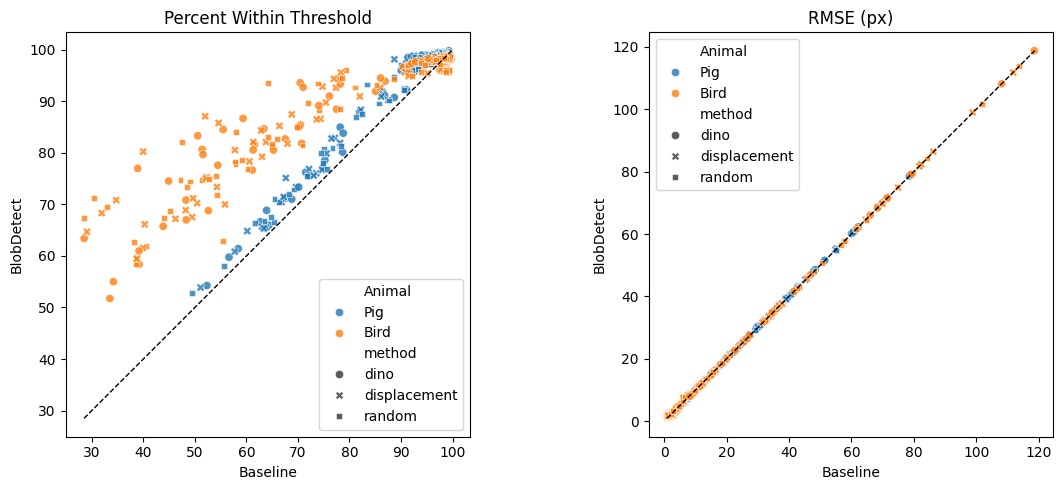

In [66]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

plots = [
    (
        "percent_points_within_threshold_baseline",
        "percent_points_within_threshold_blobDetect",
        "Percent Within Threshold",
    ),
    (
        "rmse_px_baseline",
        "rmse_px_blobDetect",
        "RMSE (px)",
    ),
]

for ax, (xcol, ycol, title) in zip(axes, plots):

    sns.scatterplot(
        data=filtered_compare_df,
        x=xcol,
        y=ycol,
        hue="Animal",        # optional
        style="method",      # optional
        alpha=0.8,
        ax=ax
    )

    # Identity line
    mn = min(filtered_compare_df[[xcol, ycol]].min())
    mx = max(filtered_compare_df[[xcol, ycol]].max())
    ax.plot([mn, mx], [mn, mx], "k--", lw=1)

    ax.set_xlabel("Baseline")
    ax.set_ylabel("BlobDetect")
    ax.set_title(title)
    ax.set_aspect("equal", adjustable="box")

plt.tight_layout()
plt.show()

In [55]:
# include statistical variation tests...

C:\Users\Salle-Cineradio\AppData\Local\Temp\ipykernel_18512\46009210.py:24: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.stripplot(


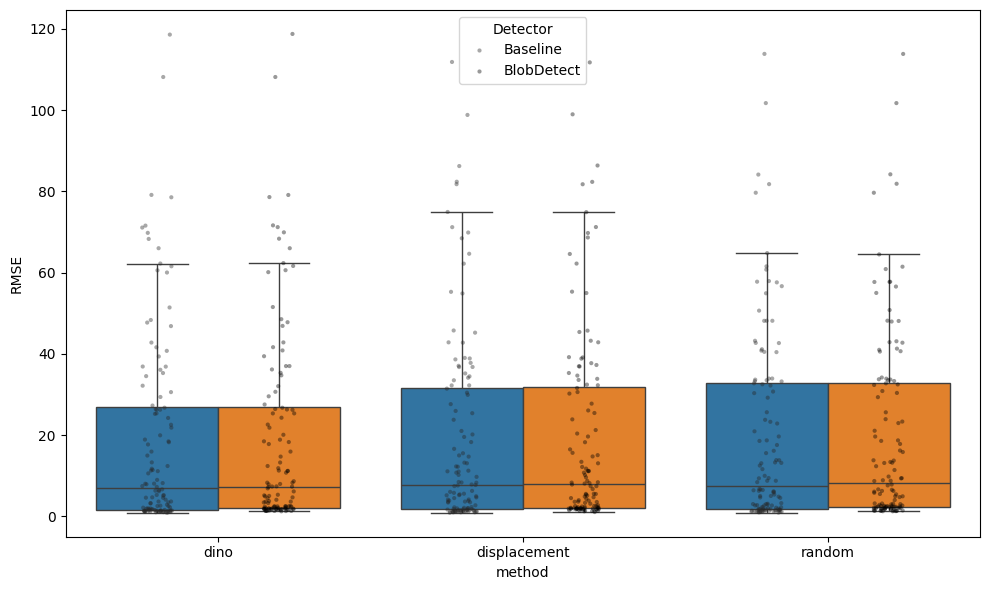

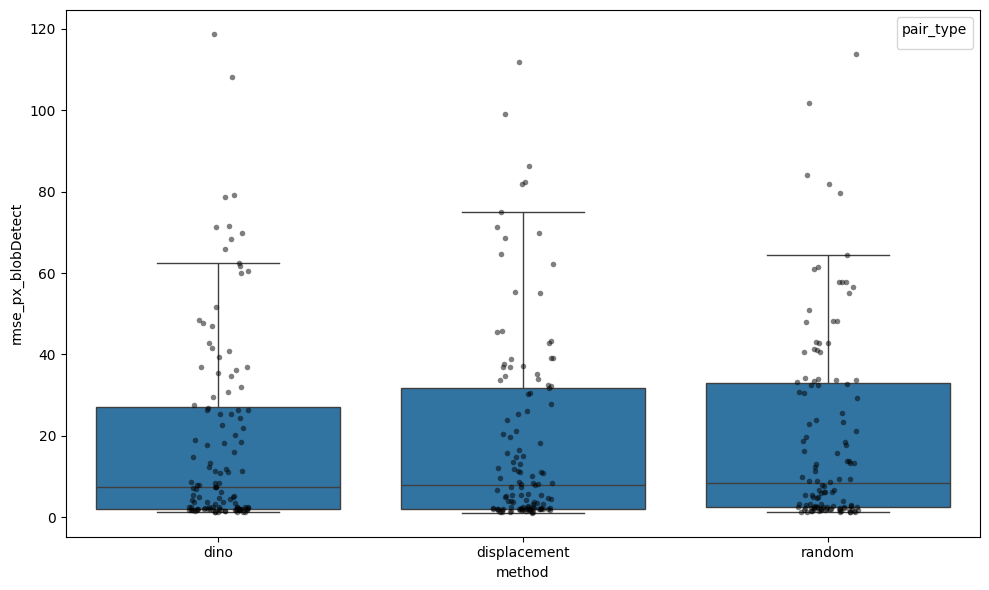

C:\Users\Salle-Cineradio\AppData\Local\Temp\ipykernel_18512\46009210.py:89: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.stripplot(


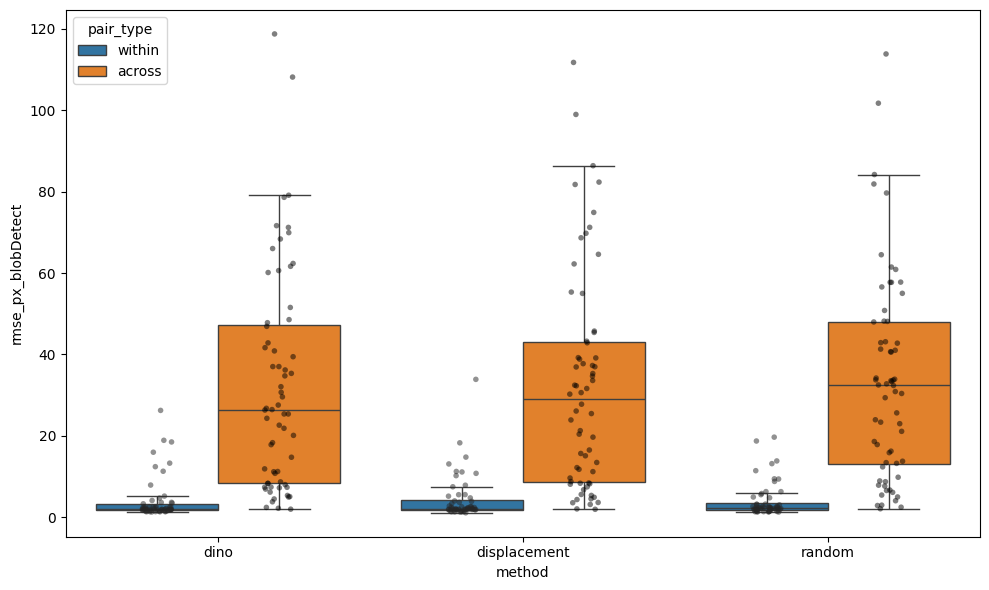

C:\Users\Salle-Cineradio\AppData\Local\Temp\ipykernel_18512\46009210.py:122: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.stripplot(


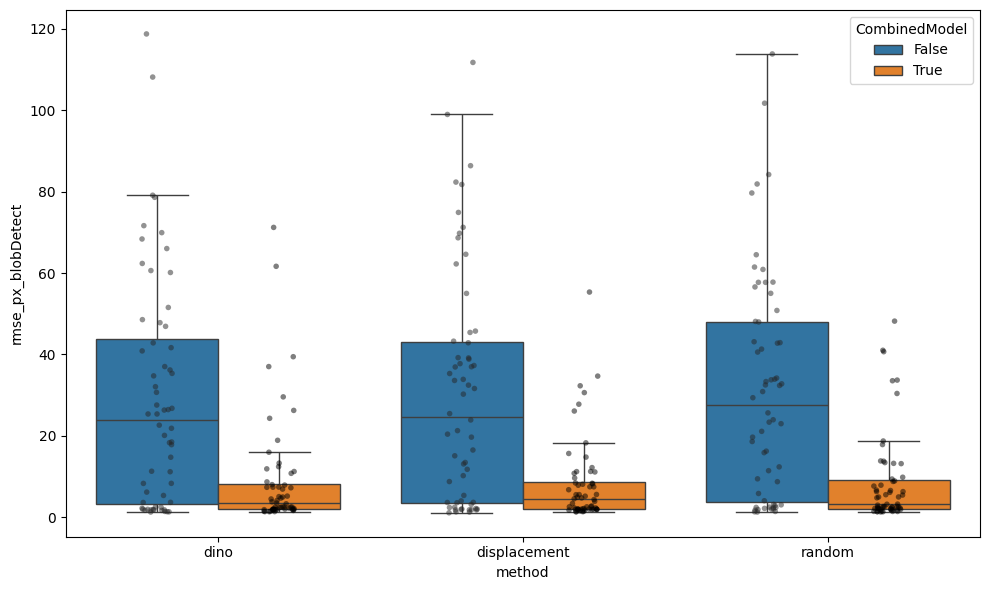

In [68]:


plot_df = filtered_compare_df.copy()
long_df = pd.concat([
    plot_df.assign(
        Detector="Baseline",
        RMSE=plot_df["rmse_px_baseline"],
    ),
    plot_df.assign(
        Detector="BlobDetect",
        RMSE=plot_df["rmse_px_blobDetect"],
    ),
], ignore_index=True)

fig, ax = plt.subplots(figsize=(10, 6))

sns.boxplot(
    data=long_df,
    x="method",
    y="RMSE",
    hue="Detector",
    showfliers=False,
    ax=ax,
)

sns.stripplot(
    data=long_df,
    x="method",
    y="RMSE",
    hue="Detector",
    dodge=True,
    color="black",
    alpha=0.4,
    size=3,
    ax=ax,
)

# Remove duplicate legend
handles, labels = ax.get_legend_handles_labels()
unique = dict(zip(labels, handles))
ax.legend(unique.values(), unique.keys(), title="Detector")

plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(10, 6))

sns.boxplot(
    data=plot_df,
    x="method",
    y="rmse_px_blobDetect",
    ax=ax,
    showfliers=False,   # optional
)


# Optional: overlay individual points
sns.stripplot(
    data=plot_df,
    x="method",
    y="rmse_px_blobDetect",
    # hue="pair_type",
    dodge=True,
    alpha=0.5,
    size=4,
    color="black",
    ax=ax,
)

# Remove the duplicate legend from the stripplot
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[:2], labels[:2], title="pair_type")

plt.tight_layout()
plt.show()


fig, ax = plt.subplots(figsize=(10, 6))

sns.boxplot(
    data=plot_df,
    x="method",
    y="rmse_px_blobDetect",
    hue="pair_type",
    ax=ax,
    showfliers=False,   # optional
)


# Optional: overlay individual points
sns.stripplot(
    data=plot_df,
    x="method",
    y="rmse_px_blobDetect",
    hue="pair_type",
    dodge=True,
    alpha=0.5,
    size=4,
    color="black",
    ax=ax,
)

# Remove the duplicate legend from the stripplot
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[:2], labels[:2], title="pair_type")

plt.tight_layout()
plt.show()


fig, ax = plt.subplots(figsize=(10, 6))

sns.boxplot(
    data=plot_df,
    x="method",
    y="rmse_px_blobDetect",
    hue="CombinedModel",
    ax=ax,
    showfliers=False,   # optional
)


# Optional: overlay individual points
sns.stripplot(
    data=plot_df,
    x="method",
    y="rmse_px_blobDetect",
    hue="CombinedModel",
    dodge=True,
    alpha=0.5,
    size=4,
    color="black",
    ax=ax,
)

# Remove the duplicate legend from the stripplot
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[:2], labels[:2], title="CombinedModel")

plt.tight_layout()
plt.show()


# plot_df = (
#     filtered_compare_df
#     .query("CombinedModel == True")
#     .loc[~filtered_compare_df["bird"].isin(["Tulio", "Pig"])]
# )

# fig, ax = plt.subplots(figsize=(8, 6))

# sns.boxplot(
#     data=plot_df,
#     x="method",
#     y="rmse_px_blobDetect",
#     hue="pair_type",          # Across vs Within
#     showfliers=False,
#     ax=ax,
# )

# sns.stripplot(
#     data=plot_df,
#     x="method",
#     y="rmse_px_blobDetect",
#     hue="pair_type",
#     dodge=True,
#     alpha=0.5,
#     size=3,
#     color="black",
#     ax=ax,
# )

# # Remove duplicate legend
# handles, labels = ax.get_legend_handles_labels()
# unique = dict(zip(labels, handles))
# ax.legend(unique.values(), unique.keys(), title="Pair Type")

# ax.set_ylabel("BlobDetect RMSE (px)")
# ax.set_xlabel("Method")
# ax.set_title("Combined model performance")

# plt.tight_layout()
# plt.show()


#### Percent Points within 3 pxs

C:\Users\Salle-Cineradio\AppData\Local\Temp\ipykernel_18512\2290435577.py:25: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.stripplot(


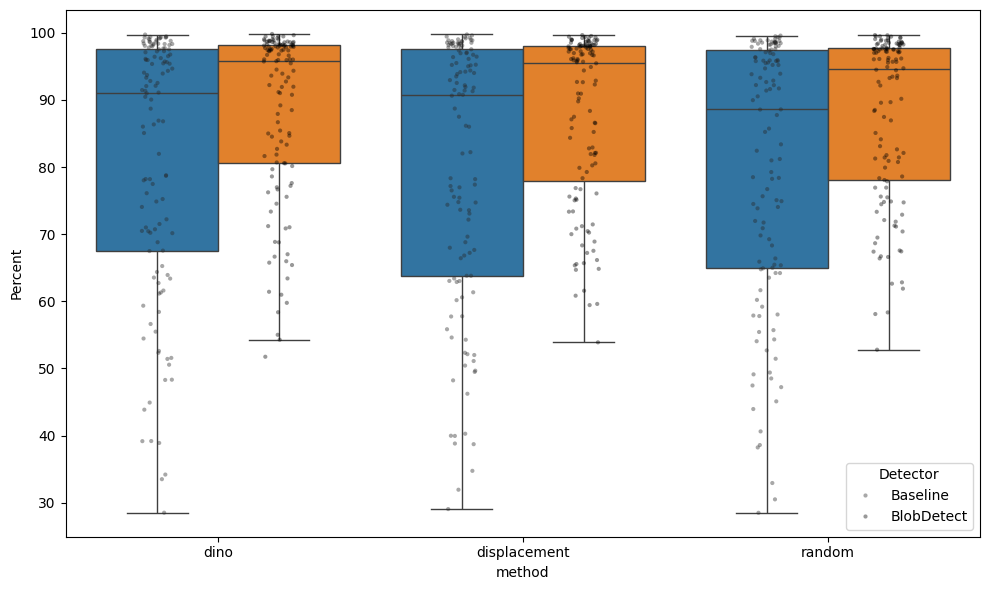

C:\Users\Salle-Cineradio\AppData\Local\Temp\ipykernel_18512\2290435577.py:59: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.stripplot(


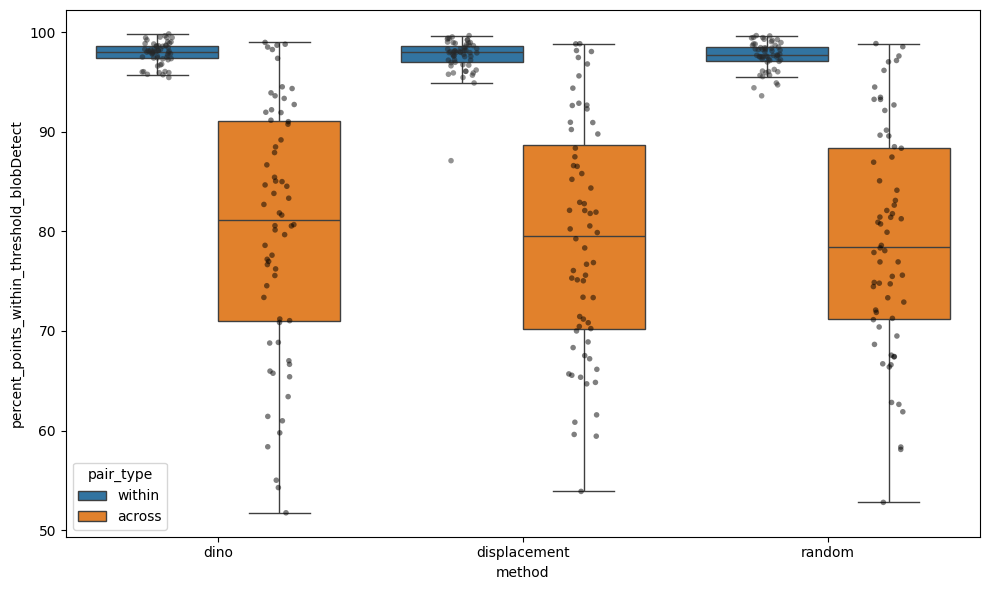

C:\Users\Salle-Cineradio\AppData\Local\Temp\ipykernel_18512\2290435577.py:91: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.stripplot(


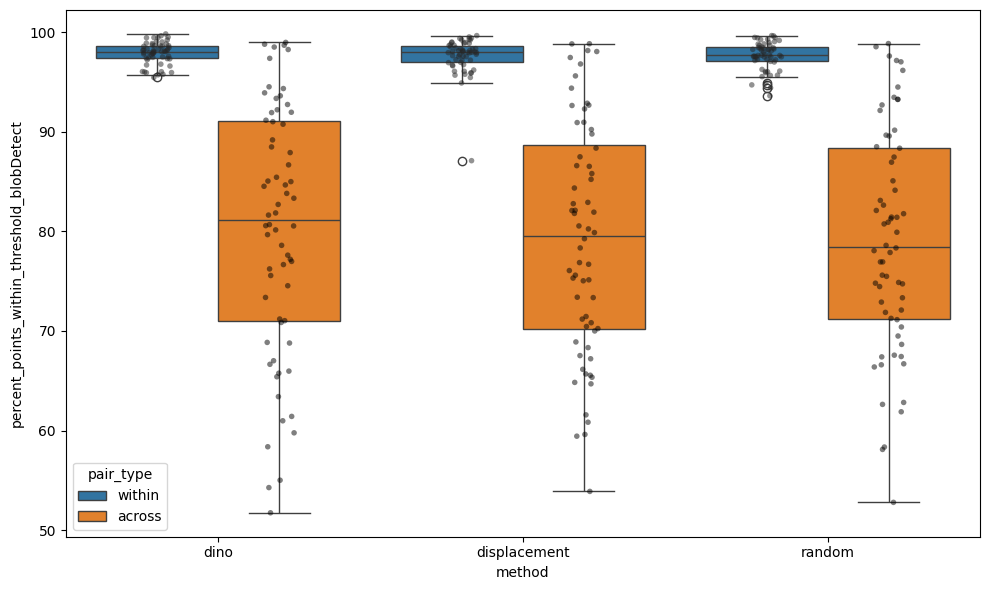

In [70]:
plot_df = filtered_compare_df.copy()

long_df = pd.concat([
    plot_df.assign(
        Detector="Baseline",
        Percent=plot_df["percent_points_within_threshold_baseline"],
    ),
    plot_df.assign(
        Detector="BlobDetect",
        Percent=plot_df["percent_points_within_threshold_blobDetect"],
    ),
], ignore_index=True)

fig, ax = plt.subplots(figsize=(10, 6))

sns.boxplot(
    data=long_df,
    x="method",
    y="Percent",
    hue="Detector",
    showfliers=False,
    ax=ax,
)

sns.stripplot(
    data=long_df,
    x="method",
    y="Percent",
    hue="Detector",
    dodge=True,
    color="black",
    alpha=0.4,
    size=3,
    ax=ax,
)

# Remove duplicate legend
handles, labels = ax.get_legend_handles_labels()
unique = dict(zip(labels, handles))
ax.legend(unique.values(), unique.keys(), title="Detector")

plt.tight_layout()
plt.show()



fig, ax = plt.subplots(figsize=(10, 6))

sns.boxplot(
    data=plot_df,
    x="method",
    y="percent_points_within_threshold_blobDetect",
    hue="pair_type",
    ax=ax,
    showfliers=False,   # optional
)

# Optional: overlay individual points
sns.stripplot(
    data=plot_df,
    x="method",
    y="percent_points_within_threshold_blobDetect",
    hue="pair_type",
    dodge=True,
    alpha=0.5,
    size=4,
    color="black",
    ax=ax,
)

# Remove the duplicate legend from the stripplot
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[:2], labels[:2], title="pair_type")

plt.tight_layout()
plt.show()


fig, ax = plt.subplots(figsize=(10, 6))

sns.boxplot(
    data=plot_df,
    x="method",
    y="percent_points_within_threshold_blobDetect",
    hue="pair_type",
    ax=ax,
    # showfliers=False,   # optional
)

# Optional: overlay individual points
sns.stripplot(
    data=plot_df,
    x="method",
    y="percent_points_within_threshold_blobDetect",
    hue="pair_type",
    dodge=True,
    alpha=0.5,
    size=4,
    color="black",
    ax=ax,
)

# Remove the duplicate legend from the stripplot
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[:2], labels[:2], title="pair_type")

plt.tight_layout()
plt.show()






In [59]:
# Generate stats to see if the 100 frames are statistically significant?

In [12]:
compare_view = pd.read_csv(r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCutExperiments\Data\evaluation_results\OverallModelEfforts-blobdetect2.csv")

In [28]:
import matplotlib as mpl

# -----------------------------
# User controls
# -----------------------------
ERROR_VIEW = "baseline"   # "baseline" | "blobDetect" | "delta"
PAIR_TYPE = "within"      # optional filter if column exists
CAMERA_FOR_ERROR_EMBED = "Cam1"
METHODS_TO_SHOW = ("random", "displacement", "dino")

# Trial folder used for embedding background cloud
# Reuses your existing variable if present
trial_name_for_plot = globals().get("TRIAL_FOR_EMBED_VIS", "DB_T16")
trial_dir_for_plot = DATA_ROOT / trial_name_for_plot

# comparison dataframe source (already built earlier in your notebook)
# expected: compare_view or blob_compare_df
comparison_df = globals().get("compare_view", globals().get("blob_compare_df", None))
if comparison_df is None:
    raise RuntimeError("comparison df not found. Run blobdetect comparison cell first (compare_view or blob_compare_df).")

# point-level errors source (needed for true per-frame RMSE)
# try in-memory first, then CSV path from blob_eval_out
# point_errors_df = None
# if "blob_eval_out" in globals():
#     # print(blob_eval_out)
#     point_errors_df = blob_eval_out.get("point_errors_df", None)
#     # print(point_errors_df)
#     if point_errors_df is None:
#         errors_csv = blob_eval_out.get("full_errors_csv", None)
#         # print(errors_csv)
#         if errors_csv is not None and Path(errors_csv).exists():
#             point_errors_df = pd.read_csv(errors_csv)

In [45]:

def _frame_rmse_from_points(df_points: pd.DataFrame) -> pd.Series:
    err_col = "distance_px"
    # print(err_col)
    # if err_col is None:
    #     raise ValueError(f"No point-error column found in point errors df. Columns: {list(df_points.columns)}")

    frame_key = "frame_id"
    # if frame_key is None:
    #     raise ValueError(f"No frame identifier column found in point errors df. Columns: {list(df_points.columns)}")

    x = df_points.copy()
    x[err_col] = pd.to_numeric(x[err_col], errors="coerce")
    x = x.dropna(subset=[err_col])

    # RMSE per frame: sqrt(mean(err^2))
    rmse = x.groupby(frame_key)[err_col].apply(lambda s: float(np.sqrt(np.mean(np.square(s.to_numpy())))))
    rmse.name = "frame_rmse"
    return rmse

def _select_rows_for_method(df: pd.DataFrame, method: str, nframes: int, trial_name: int, pair_type: str | None):
    x = df.copy()
    if "method" in x.columns:
        x = x[x["method"].astype(str).str.lower().eq(method.lower())]
    if "nframes" in x.columns:
        x = x[pd.to_numeric(x["nframes"], errors="coerce").eq(int(nframes))]
    if "eval_trial" in x.columns:
        x = x[x["eval_trial"].astype(int).eq(int(trial_name))]
    if pair_type is not None and "pair_type" in x.columns:
        x = x[x["pair_type"].astype(str).str.lower().eq(pair_type.lower())]
    return x

def plot_error_colored_embeddings_1x3(
    trial_dir: Path,
    comparison_df: pd.DataFrame,
    axes: int | None,
    point_errors_df: pd.DataFrame | None,
    error_view: str = "baseline",
    nframes: int = 50,
    camera: str = "Cam1",
    methods=("random", "displacement", "dino"),
    batch_size: int = 32,
):
    if not trial_dir.exists():
        raise FileNotFoundError(f"Trial folder not found: {trial_dir}")

    complete_images = _list_images_sorted(trial_dir / "CompleteSet" / camera)
    test_images = _list_images_sorted(trial_dir / "test" / camera)
    if len(complete_images) == 0:
        raise RuntimeError(f"No complete-set images found: {trial_dir / 'CompleteSet' / camera}")
    if len(test_images) == 0:
        raise RuntimeError(f"No test images found: {trial_dir / 'test' / camera}")

    # Embeddings (all frames)
    model, transform, device = _build_dino_model_once(model_name=DINO_MODEL_NAME)
    emb = _compute_embeddings_with_model(
        complete_images,
        model=model,
        transform=transform,
        device=device,
        batch_size=batch_size,
    )

    if umap is not None:
        reducer = umap.UMAP(
            n_neighbors=UMAP_NEIGHBORS,
            min_dist=UMAP_MIN_DIST,
            metric=UMAP_METRIC,
            random_state=RANDOM_SEED,
        )
        emb2d = reducer.fit_transform(emb)
        xlab, ylab = "UMAP 1", "UMAP 2"
    else:
        from sklearn.decomposition import PCA
        emb2d = PCA(n_components=2, random_state=RANDOM_SEED).fit_transform(emb)
        xlab, ylab = "PC 1", "PC 2"

    complete_name_to_idx = {p.name: i for i, p in enumerate(complete_images)}
    test_names = [p.name for p in test_images]
    test_idx_global = np.asarray([complete_name_to_idx[n] for n in test_names if n in complete_name_to_idx], dtype=int)

    # Build per-method frame RMSE vectors for test frames
        # Build per-method frame RMSE vectors for test frames
    method_to_idx = {}
    method_to_vals = {}

    fallback_metric_col = {
        "baseline": "rmse_px_baseline",
        "blobDetect": "rmse_px_blobDetect",
        "delta": "delta_rmse_px_blob_minus_base",
    }[error_view]

    for method in methods:

        vals = None

        # Preferred: point-level frame RMSE
        if point_errors_df is not None:

            match = re.search(r"_T(\d+)", trial_dir.name)
            trial_num = int(match.group(1)) if match else None

            p = _select_rows_for_method(
                point_errors_df,
                method,
                nframes,
                trial_num,
                PAIR_TYPE,
            )

            if error_view in ("baseline", "blobDetect"):

                if "prediction_variant" in p.columns:
                    p = p[
                        p["prediction_variant"]
                        .astype(str)
                        .str.lower()
                        .eq(error_view.lower())
                    ]

                try:
                    frame_rmse = _frame_rmse_from_points(p)

                    # print(method)
                    # print(frame_rmse.head())
                    # print(frame_rmse.describe())

                    vals = []

                    for i_local, img_name in enumerate(test_names):

                        if img_name in frame_rmse.index:
                            vals.append(float(frame_rmse.loc[img_name]))
                        elif i_local in frame_rmse.index:
                            vals.append(float(frame_rmse.loc[i_local]))
                        else:
                            vals.append(np.nan)

                    vals = np.asarray(vals, dtype=float)

                except Exception as e:
                    print(e)
                    vals = None

            elif error_view == "delta":

                p0 = p.copy()
                p1 = p.copy()

                if "prediction_variant" in p.columns:
                    p0 = p0[
                        p0["prediction_variant"]
                        .astype(str)
                        .str.lower()
                        .eq("baseline")
                    ]

                    p1 = p1[
                        p1["prediction_variant"]
                        .astype(str)
                        .str.lower()
                        .eq("blobdetect")
                    ]

                try:

                    r0 = _frame_rmse_from_points(p0)
                    r1 = _frame_rmse_from_points(p1)

                    vals = []

                    for i_local, img_name in enumerate(test_names):

                        k_name = (
                            img_name
                            if img_name in r0.index or img_name in r1.index
                            else None
                        )

                        k_idx = (
                            i_local
                            if i_local in r0.index or i_local in r1.index
                            else None
                        )

                        v0 = (
                            float(r0.loc[k_name])
                            if (k_name is not None and k_name in r0.index)
                            else (
                                float(r0.loc[k_idx])
                                if (k_idx is not None and k_idx in r0.index)
                                else np.nan
                            )
                        )

                        v1 = (
                            float(r1.loc[k_name])
                            if (k_name is not None and k_name in r1.index)
                            else (
                                float(r1.loc[k_idx])
                                if (k_idx is not None and k_idx in r1.index)
                                else np.nan
                            )
                        )

                        vals.append(v1 - v0)

                    vals = np.asarray(vals, dtype=float)
                    vals = np.clip(vals, 0, None)

                except Exception as e:
                    print(e)
                    vals = None

        # Fallback: run-level scalar
        if vals is None:

            match = re.search(r"_T(\d+)", trial_dir.name)
            trial_num = int(match.group(1)) if match else None

            c = _select_rows_for_method(
                comparison_df,
                method,
                nframes,
                trial_num,
                PAIR_TYPE,
            )

            if fallback_metric_col not in c.columns or len(c) == 0:
                scalar = np.nan
            else:
                scalar = float(
                    pd.to_numeric(
                        c[fallback_metric_col],
                        errors="coerce",
                    ).mean()
                )

                if error_view == "delta":
                    scalar = max(0.0, scalar)

            vals = np.full(
                len(test_idx_global),
                scalar,
                dtype=float,
            )

        # print(method)
        # print(vals.shape)
        # print(np.nanmin(vals), np.nanmax(vals))
        # print(f"unique values = {len(np.unique(vals))}")

        valid = np.isfinite(vals)

        method_to_idx[method] = test_idx_global[valid]
        method_to_vals[method] = vals[valid]


    # ====================================================
    # Plot bird trial on rows, columns are selection method
    # ====================================================

    created_fig = False

    if axes is None:
        fig, axes = plt.subplots(
            1, 3,
            figsize=(18, 5),
            sharex=True,
            sharey=True,
        )
        own_figure = True
    else:
        fig = axes[0].figure
        own_figure = False
    cmap = plt.cm.Reds

    # Global color scale across all methods
    all_vals = np.concatenate(
        [v for v in method_to_vals.values() if len(v) > 0]
    )

    global_vmax = np.nanmax(all_vals)
    if not np.isfinite(global_vmax) or global_vmax <= 0:
        global_vmax = 1.0

    norm = mpl.colors.Normalize(vmin=0.0, vmax=global_vmax)



    for ax, method in zip(axes, methods):

        ax.scatter(
            emb2d[:, 0],
            emb2d[:, 1],
            s=12,
            c="#1b1b1b",
            alpha=0.18,
            linewidths=0,
        )

        idx = method_to_idx.get(method, np.asarray([], dtype=int))
        vals = method_to_vals.get(method, np.asarray([], dtype=float))

        if len(idx) > 0:

            vmax = np.nanmax(vals)

            if not np.isfinite(vmax) or vmax <= 0:
                vmax = 1.0

            norm = mpl.colors.Normalize(
                vmin=0.0,
                vmax=vmax,
            )

            sc = ax.scatter(
                emb2d[idx, 0],
                emb2d[idx, 1],
                c=idx,
                cmap=cmap,
                # norm=norm,
                s=34,
                edgecolors="black",
                linewidths=0.25,
                alpha=0.95,
            )

                    # If you want unique color bars
            # cbar = fig.colorbar(
            #     sc,
            #     ax=ax,
            #     fraction=0.046,
            #     pad=0.04,
            # )

            # cbar.set_label(f"Frame RMSE ({error_view})")

        ax.set_title(method)
        ax.set_xlabel(xlab)
    
    # fig.colorbar(
    #     mpl.cm.ScalarMappable(norm=norm, cmap=cmap),
    #     ax=axes,
    #     fraction=0.025,
    #     pad=0.02,
    #     label=f"Frame RMSE ({error_view})",
    # )
    axes[0].set_ylabel(ylab)
    fig.suptitle(
            f"{trial_dir.name} | {camera} | nframes={nframes} | pair={PAIR_TYPE} | error={error_view}",
            y=1.02,
        )
    if own_figure:
        plt.tight_layout()
        plt.show()

In [5]:
point_errors_df_DB = pd.read_csv(r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCutExperiments\Data\evaluation_results\DavidBowie_within_across_point_errors_with_blobDetect_20260715_160251.csv")

In [16]:
import matplotlib as mpl

# -----------------------------
# User controls
# -----------------------------
ERROR_VIEW = "baseline"   # "baseline" | "blobDetect" | "delta"
PAIR_TYPE = "within"      # optional filter if column exists
CAMERA_FOR_ERROR_EMBED = "Cam1"
METHODS_TO_SHOW = ("random", "displacement", "dino")

# Trial folder used for embedding background cloud
# Reuses your existing variable if present
trial_name_for_plot = globals().get("TRIAL_FOR_EMBED_VIS", "DB_T16")
trial_dir_for_plot = DATA_ROOT / trial_name_for_plot
trial_dir_for_plot = Path(r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCutExperiments\Data\DB_T16")
print(trial_dir_for_plot)
# comparison dataframe source (already built earlier in your notebook)
# expected: compare_view or blob_compare_df
comparison_df = globals().get("compare_view", globals().get("blob_compare_df", None))
if comparison_df is None:
    raise RuntimeError("comparison df not found. Run blobdetect comparison cell first (compare_view or blob_compare_df).")

# # point-level errors source (needed for true per-frame RMSE)
# # try in-memory first, then CSV path from blob_eval_out
# point_errors_df = None
# if "blob_eval_out" in globals():
#     # print(blob_eval_out)
#     point_errors_df = blob_eval_out.get("point_errors_df", None)
#     # print(point_errors_df)
#     if point_errors_df is None:
#         errors_csv = blob_eval_out.get("full_errors_csv", None)
#         # print(errors_csv)
#         if errors_csv is not None and Path(errors_csv).exists():
#             point_errors_df = pd.read_csv(errors_csv)

C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCutExperiments\Data\DB_T16


Plotting DB_T15...


Using cache found in C:\Users\Salle-Cineradio/.cache\torch\hub\facebookresearch_dinov2_main
c:\Users\Salle-Cineradio\Documents\miniconda\envs\DEEPLABCUT\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Plotting DB_T16...


Using cache found in C:\Users\Salle-Cineradio/.cache\torch\hub\facebookresearch_dinov2_main
c:\Users\Salle-Cineradio\Documents\miniconda\envs\DEEPLABCUT\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Plotting DB_T17...


Using cache found in C:\Users\Salle-Cineradio/.cache\torch\hub\facebookresearch_dinov2_main
c:\Users\Salle-Cineradio\Documents\miniconda\envs\DEEPLABCUT\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


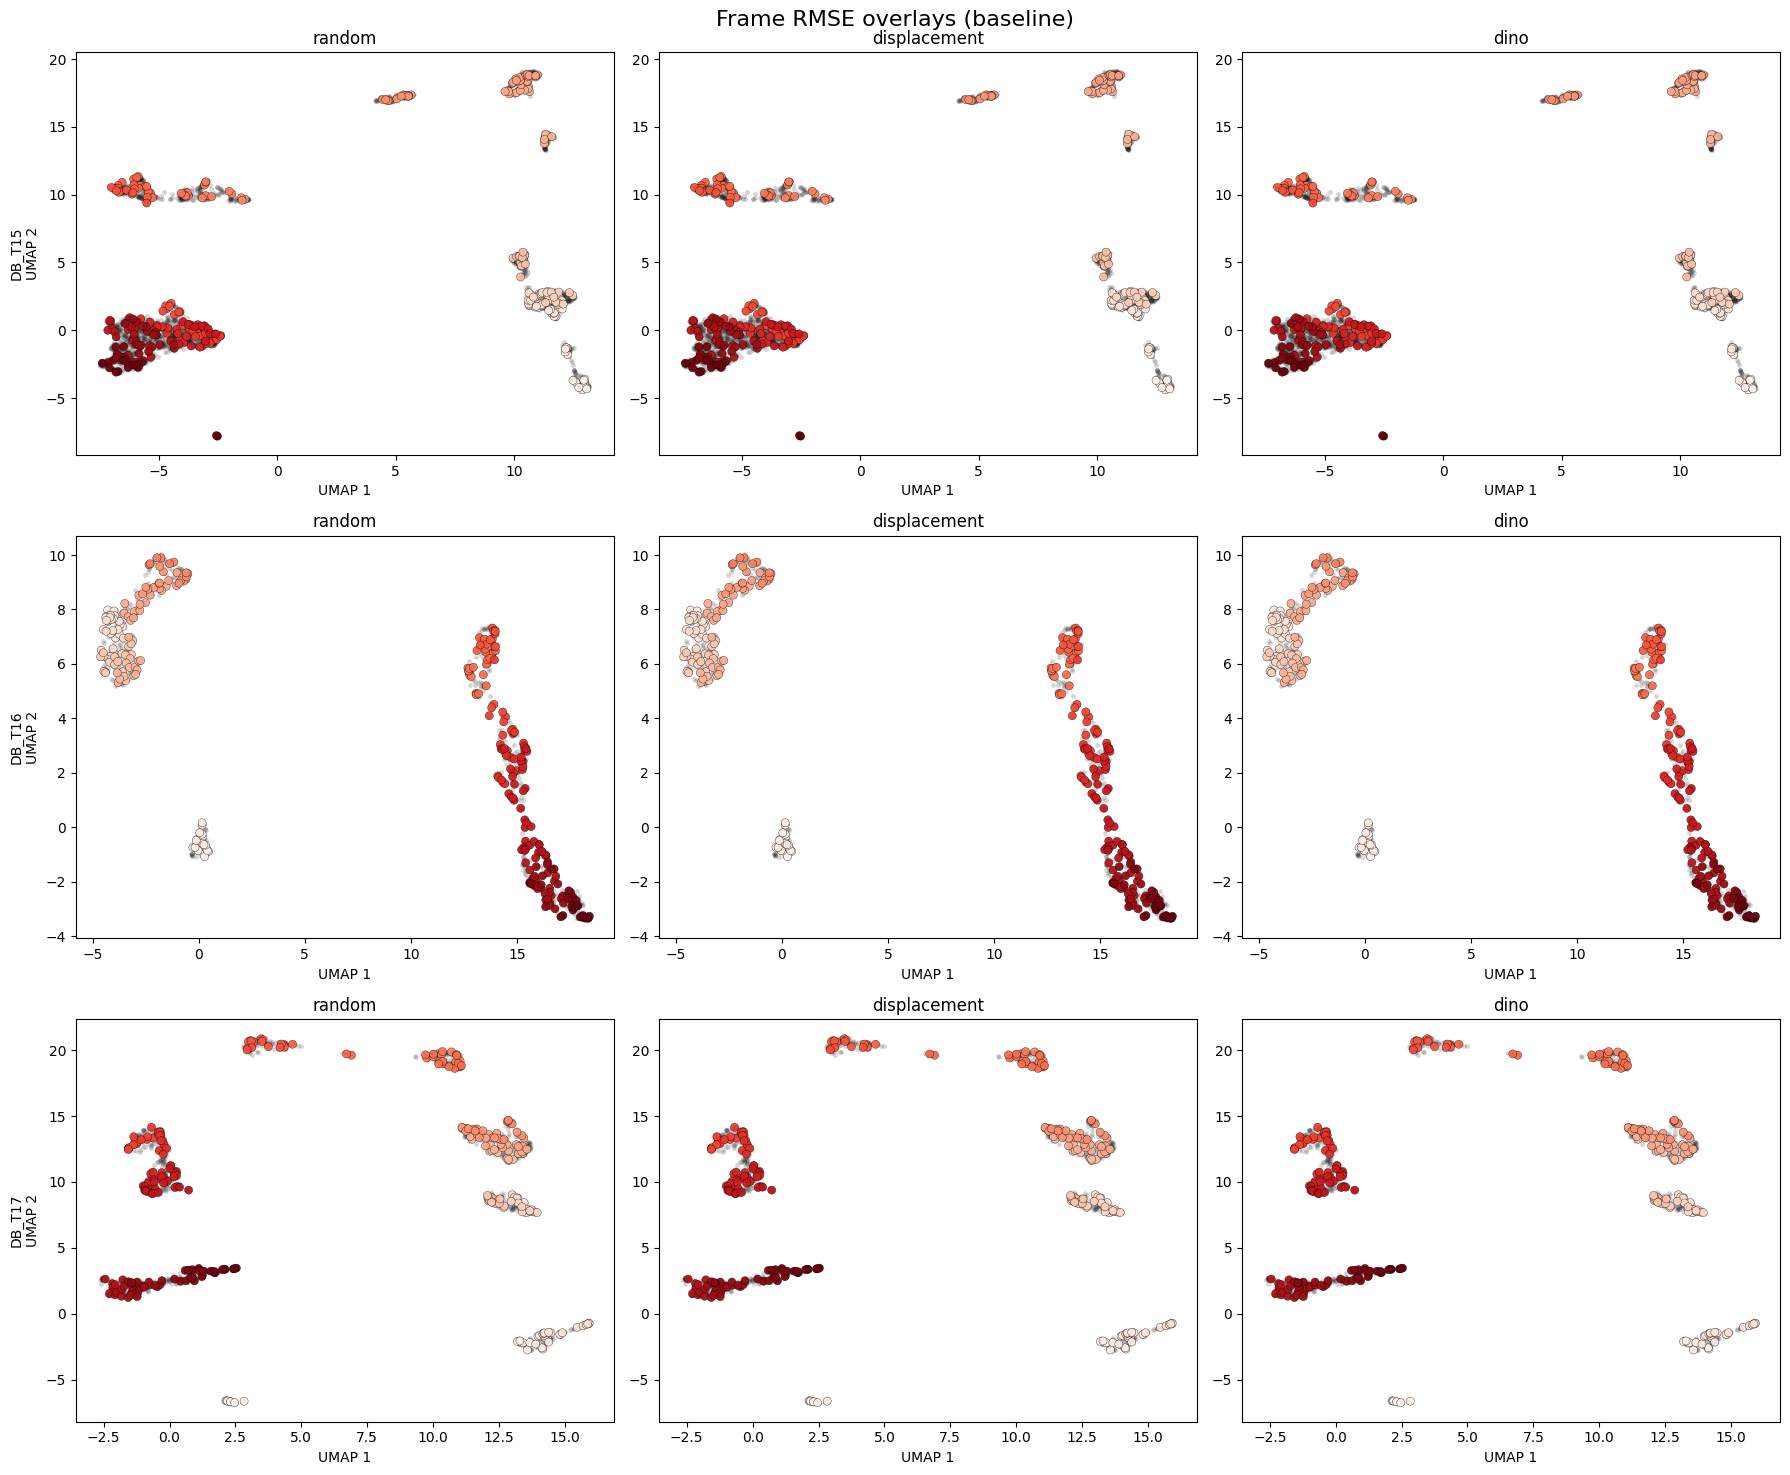

In [46]:
data_root = Path(
    r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCutExperiments\Data"
)

dirs = [d for d in sorted(data_root.glob("DB_T*")) if d.is_dir()]

fig, axes = plt.subplots(
    len(dirs),
    3,
    figsize=(18, 5 * len(dirs)),
    facecolor="white",
)

if len(dirs) == 1:
    axes = np.expand_dims(axes, axis=0)

for row, trial_dir in enumerate(dirs):

    print(f"Plotting {trial_dir.name}...")

    plot_error_colored_embeddings_1x3(
        trial_dir=trial_dir,
        comparison_df=comparison_df,
        point_errors_df=point_errors_df_DB,
        error_view=ERROR_VIEW,
        nframes=NFRAMES_FOR_METHOD_METADATA,
        camera=CAMERA_FOR_ERROR_EMBED,
        methods=METHODS_TO_SHOW,
        batch_size=DINO_BATCH_SIZE,
        axes=axes[row],          # <-- pass one row of axes
    )

    axes[row, 0].set_ylabel(f"{trial_dir.name}\nUMAP 2")

fig.suptitle(
    f"Frame RMSE overlays ({ERROR_VIEW})",
    fontsize=16,
)

plt.tight_layout()
plt.show()

In [7]:
from collections import defaultdict
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl


def build_unified_embedding_results(
    trial_dirs,
    comparison_df,
    point_errors_df=None,
    error_view="baseline",
    camera="Cam1",
    methods=("random", "displacement", "dino"),
    nframes=50,
    batch_size=32,
):
    """
    Compute one global DINO+UMAP space over all trials.

    Returns
    -------
    results:
        {
          "across": {
              method: {
                  "xy": Nx2,
                  "vals": N
              }
          },
          "within": ...
        }

    """

    # -------------------------------------------------------
    # 1. Collect every image from every trial
    # -------------------------------------------------------

    all_complete_images = []
    trial_info = {}

    for trial_dir in trial_dirs:

        complete_images = _list_images_sorted(
            trial_dir / "CompleteSet" / camera
        )

        test_images = _list_images_sorted(
            trial_dir / "test" / camera
        )

        if len(complete_images) == 0:
            continue

        start_idx = len(all_complete_images)

        all_complete_images.extend(complete_images)

        trial_info[trial_dir] = {
            "complete_images": complete_images,
            "test_images": test_images,
            "offset": start_idx,
        }


    print(
        f"Total images for unified embedding: {len(all_complete_images)}"
    )


    # -------------------------------------------------------
    # 2. DINO embeddings ONCE
    # -------------------------------------------------------

    model, transform, device = _build_dino_model_once(
        model_name=DINO_MODEL_NAME
    )

    all_emb = _compute_embeddings_with_model(
        all_complete_images,
        model=model,
        transform=transform,
        device=device,
        batch_size=batch_size,
    )


    # -------------------------------------------------------
    # 3. One UMAP for everything
    # -------------------------------------------------------

    if umap is not None:

        reducer = umap.UMAP(
            n_neighbors=UMAP_NEIGHBORS,
            min_dist=UMAP_MIN_DIST,
            metric=UMAP_METRIC,
            random_state=RANDOM_SEED,
        )

        all_xy = reducer.fit_transform(all_emb)

        xlab = "UMAP 1"
        ylab = "UMAP 2"

    else:

        from sklearn.decomposition import PCA

        reducer = PCA(
            n_components=2,
            random_state=RANDOM_SEED,
        )

        all_xy = reducer.fit_transform(all_emb)

        xlab = "PC 1"
        ylab = "PC 2"


    # -------------------------------------------------------
    # 4. Accumulate results
    # -------------------------------------------------------

    results = {
        "across": defaultdict(
            lambda: {"xy": [], "vals": []}
        ),
        "within": defaultdict(
            lambda: {"xy": [], "vals": []}
        ),
    }


    fallback_metric_col = {
        "baseline": "rmse_px_baseline",
        "blobDetect": "rmse_px_blobDetect",
        "delta": "delta_rmse_px_blob_minus_base",
    }[error_view]


    pair_types = ["across", "within"]

    for trial_dir, info in trial_info.items():

        complete_offset = info["offset"]

        complete_name_to_idx = {
            p.name: complete_offset + i
            for i, p in enumerate(info["complete_images"])
        }

        test_names = [
            p.name
            for p in info["test_images"]
        ]

        test_idx_global = np.asarray(
            [
                complete_name_to_idx[n]
                for n in test_names
                if n in complete_name_to_idx
            ],
            dtype=int,
        )


        for pair in pair_types:

            print(
                trial_dir.name,
                "pair=",
                pair,
                "test frames=",
                len(test_idx_global),
            )


            for method in methods:

                vals = None


                if point_errors_df is not None:

                    match = re.search(
                        r"_T(\d+)",
                        trial_dir.name
                    )

                    trial_num = (
                        int(match.group(1))
                        if match
                        else None
                    )


                    p = _select_rows_for_method(
                        point_errors_df,
                        method,
                        nframes,
                        trial_num,
                        pair,        # <-- use loop variable
                    )


                    try:

                        if error_view in (
                            "baseline",
                            "blobDetect"
                        ):

                            if "prediction_variant" in p.columns:
                                p = p[
                                    p["prediction_variant"]
                                    .astype(str)
                                    .str.lower()
                                    .eq(error_view.lower())
                                ]


                            frame_rmse = _frame_rmse_from_points(p)


                            vals = []

                            for i, name in enumerate(test_names):

                                if name in frame_rmse.index:
                                    vals.append(
                                        float(frame_rmse.loc[name])
                                    )

                                elif i in frame_rmse.index:
                                    vals.append(
                                        float(frame_rmse.loc[i])
                                    )

                                else:
                                    vals.append(np.nan)


                            vals = np.asarray(vals)


                        elif error_view == "delta":

                            # keep your delta calculation here
                            pass


                    except Exception:
                        vals = None


                # fallback scalar

                if vals is None:

                    c = _select_rows_for_method(
                        comparison_df,
                        method,
                        nframes,
                        trial_num,
                        PAIR_TYPE,
                    )


                    scalar = (
                        pd.to_numeric(
                            c[fallback_metric_col],
                            errors="coerce",
                        ).mean()
                        if len(c)
                        else np.nan
                    )


                    vals = np.full(
                        len(test_idx_global),
                        scalar,
                    )


                valid = np.isfinite(vals)


                results[pair][method]["xy"].append(
                    all_xy[test_idx_global[valid]]
                )

                results[pair][method]["vals"].append(
                    vals[valid]
                )


    # concatenate

    for pair in results:
        for method in methods:

            xy_list = results[pair][method]["xy"]
            val_list = results[pair][method]["vals"]

            if len(xy_list) == 0:
                print(
                    f"No data for pair={pair}, method={method}"
                )

                results[pair][method]["xy"] = np.empty((0, 2))
                results[pair][method]["vals"] = np.empty((0,))

            else:
                results[pair][method]["xy"] = np.vstack(xy_list)
                results[pair][method]["vals"] = np.concatenate(val_list)

    return results, xlab, ylab

In [10]:
def plot_unified_embedding_results(
    results,
    methods=("random", "displacement", "dino"),
    xlab="UMAP 1",
    ylab="UMAP 2",
    error_view="baseline",
):

    fig, axes = plt.subplots(
        2,
        len(methods),
        figsize=(6 * len(methods), 10),
        sharex=True,
        sharey=True,
    )


    cmap = plt.cm.Reds


    # all_vals = np.concatenate(
    #     [
    #         results[p][m]["vals"]
    #         for p in ("across", "within")
    #         for m in methods
    #     ]
    # )


    # norm = mpl.colors.Normalize(
    #     vmin=0,
    #     vmax=np.nanmax(all_vals),
    # )
    all_vals = np.concatenate(
        [
            results[p][m]["vals"]
            for p in ("across", "within")
            for m in methods
            if len(results[p][m]["vals"]) > 0
        ]
    )

    # Remove invalid values
    all_vals = all_vals[np.isfinite(all_vals)]

    # Log scale cannot use zero
    positive_vals = all_vals[all_vals > 0]

    vmin = np.nanmin(positive_vals)
    vmax = np.nanmax(positive_vals)

    norm = mpl.colors.LogNorm(
        vmin=vmin,
        vmax=vmax,
    )

    for r, pair in enumerate(
        ["across", "within"]
    ):

        for c, method in enumerate(methods):

            ax = axes[r, c]

            xy = results[pair][method]["xy"]
            vals = results[pair][method]["vals"]

            if len(vals) > 0:

                # vals = results[pair][method]["vals"]

                # # avoid zeros on log scale
                # vals_plot = np.clip(
                #     vals,
                #     vmin,
                #     None,
                # )

                # ax.scatter(
                #     xy[:,0],
                #     xy[:,1],
                #     s=38,
                #     c=vals_plot,
                #     cmap=cmap,
                #     norm=norm,
                #     edgecolors="black",
                #     linewidths=0.25,
                #     alpha=0.9,
                # )
                n_frames = xy.shape[0]
                frame_idx = np.arange(n_frames)

                norm = mpl.colors.Normalize(
                    vmin=0,
                    vmax=n_frames - 1,
                )

                ax.scatter(
                    xy[:, 0],
                    xy[:, 1],
                    s=38,
                    c=frame_idx,
                    cmap=cmap,
                    norm=norm,
                    edgecolors="black",
                    linewidths=0.25,
                    alpha=0.9,
                )
            else:
                ax.text(
                    0.5,
                    0.5,
                    "No data",
                    transform=ax.transAxes,
                    ha="center",
                    va="center",
                )


            if r == 0:
                ax.set_title(method)


            if c == 0:
                ax.set_ylabel(pair.capitalize())


            ax.grid(alpha=0.15)


    fig.supxlabel(xlab)
    fig.supylabel(ylab)


    # fig.colorbar(
    #     mpl.cm.ScalarMappable(
    #         norm=norm,
    #         cmap=cmap,
    #     ),
    #     ax=axes,
    #     fraction=0.025,
    #     pad=0.02,
    #     label=f"Frame RMSE ({error_view})",
    # )
    fig.colorbar(
        mpl.cm.ScalarMappable(
            norm=norm,
            cmap=cmap,
        ),
        ax=axes,
        fraction=0.025,
        pad=0.02,
        label=f"log(Frame RMSE) ({error_view})",
    )

    plt.tight_layout()
    plt.show()

Total images for unified embedding: 5302


Using cache found in C:\Users\Salle-Cineradio/.cache\torch\hub\facebookresearch_dinov2_main
c:\Users\Salle-Cineradio\Documents\miniconda\envs\DEEPLABCUT\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


DB_T15 pair= across test frames= 300
DB_T15 pair= within test frames= 300
DB_T16 pair= across test frames= 300
DB_T16 pair= within test frames= 300
DB_T17 pair= across test frames= 300
DB_T17 pair= within test frames= 300


C:\Users\Salle-Cineradio\AppData\Local\Temp\ipykernel_26720\3654609082.py:156: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


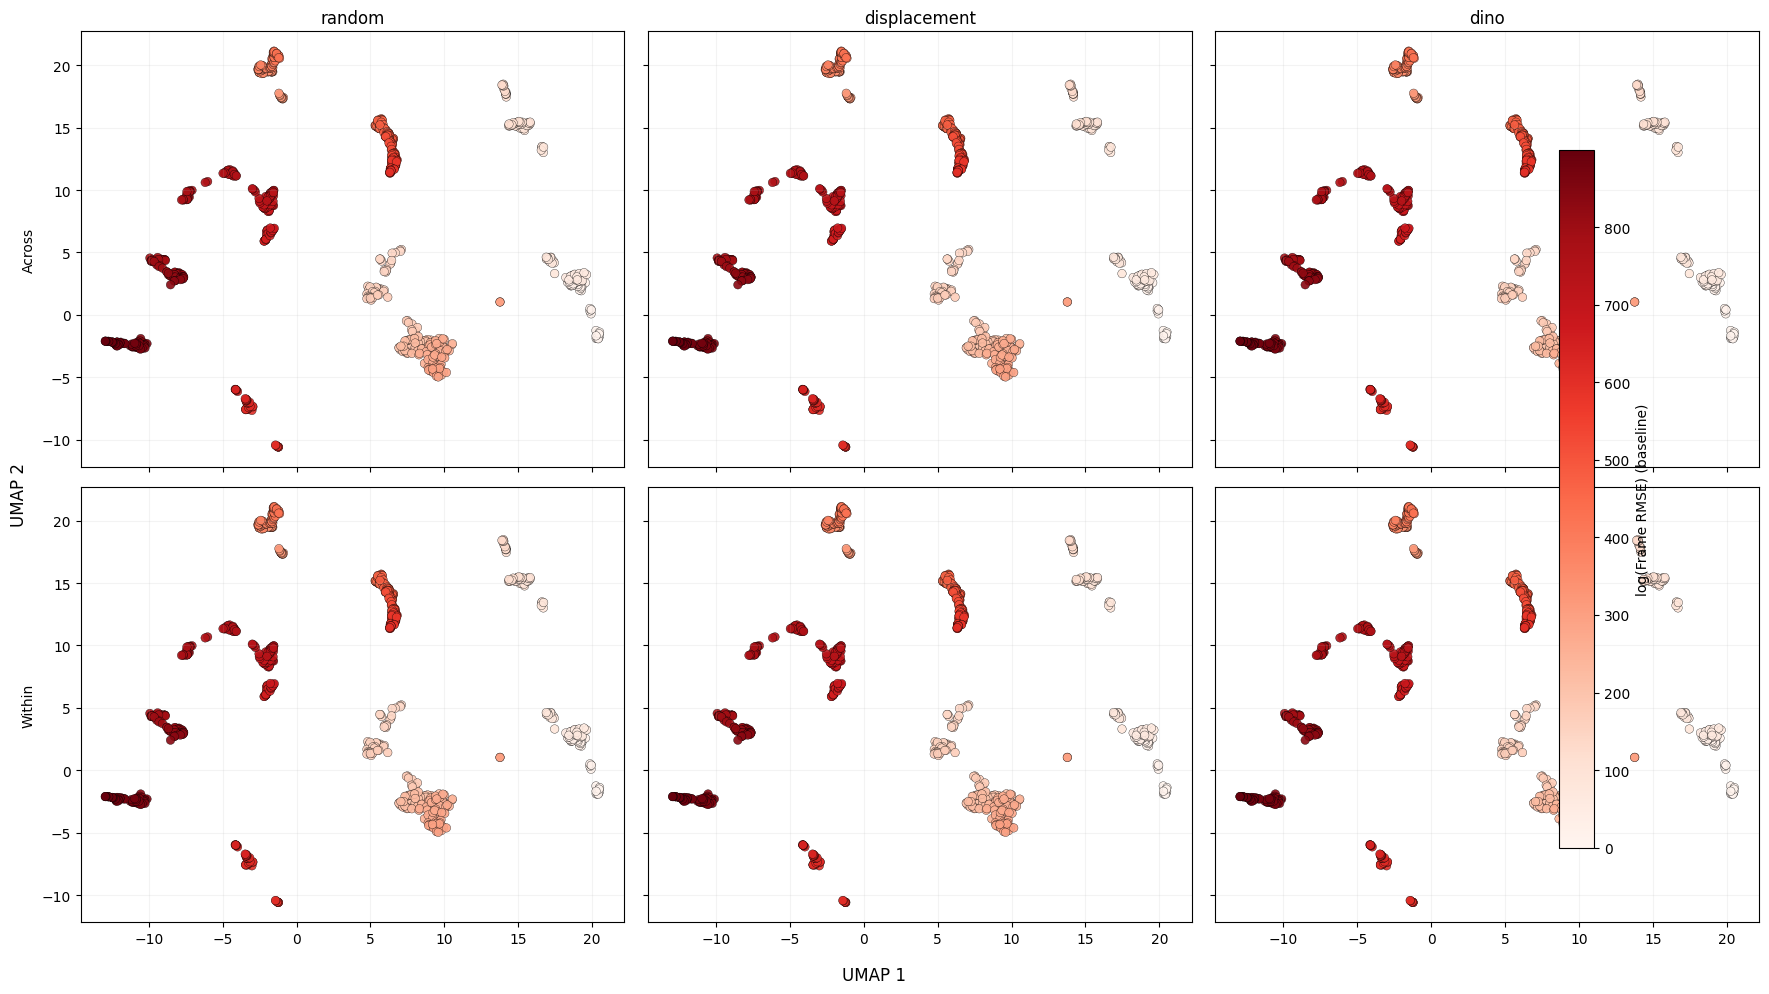

In [25]:
data_root = Path(
    r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCutExperiments\Data"
)

dirs = [d for d in sorted(data_root.glob("DB_T*")) if d.is_dir()]

results, xlab, ylab = build_unified_embedding_results(
    dirs,
    comparison_df,
    point_errors_df_DB,
    error_view="baseline",
    camera="Cam1",
)


plot_unified_embedding_results(
    results,
    error_view="baseline",
    xlab=xlab,
    ylab=ylab,
)

In [26]:
point_errors_df_tulio = pd.read_csv(r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCutExperiments\Data\evaluation_results\Tulio_within_across_point_errors_with_blobDetect_20260715_161004.csv")

Total images for unified embedding: 4078


Using cache found in C:\Users\Salle-Cineradio/.cache\torch\hub\facebookresearch_dinov2_main
c:\Users\Salle-Cineradio\Documents\miniconda\envs\DEEPLABCUT\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Tulio_T10 pair= across test frames= 300
Tulio_T10 pair= within test frames= 300
Tulio_T5 pair= across test frames= 300
Tulio_T5 pair= within test frames= 300


C:\Users\Salle-Cineradio\AppData\Local\Temp\ipykernel_26720\3654609082.py:156: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


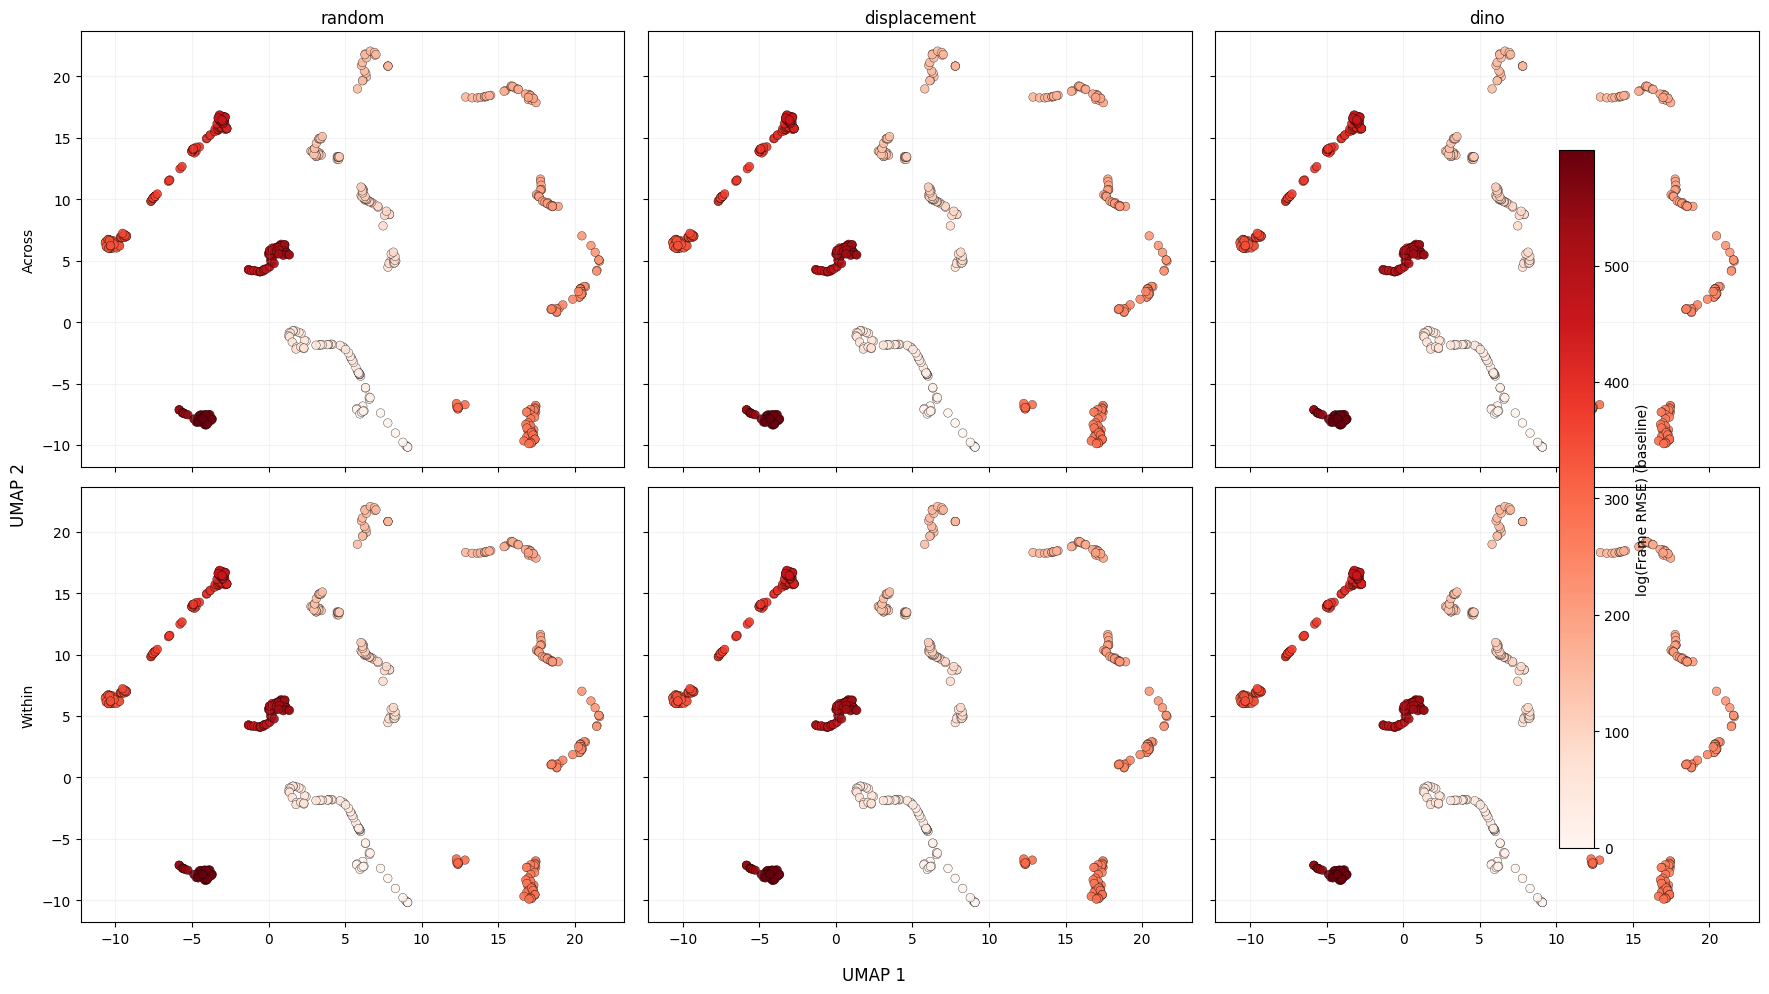

In [27]:
data_root = Path(
    r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCutExperiments\Data"
)

dirs = [d for d in sorted(data_root.glob("Tulio_T*")) if d.is_dir()]

results, xlab, ylab = build_unified_embedding_results(
    dirs,
    comparison_df,
    point_errors_df_tulio,
    error_view="baseline",
    camera="Cam1",
)


plot_unified_embedding_results(
    results,
    error_view="baseline",
    xlab=xlab,
    ylab=ylab,
)

# ---------------------------------------------------------------------

### Ensemble Training

#### Needs adjustment to take entire set of data the we can accurately compare the others!

In [118]:
from pathlib import Path
from itertools import combinations
from shutil import copy2
import pandas as pd


root = Path(
    r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCutExperiments\Data"
)

out_root = Path(
    r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCutExperiments\CombinedTrials"
)


def load_labels(csv_path):
    return pd.read_csv(csv_path)


for bird in sorted({p.name.split("_T")[0] for p in root.glob("*_T*")}):

    trials = sorted(root.glob(f"Tulio_T*"))

    # Every pair of trials
    for trial1, trial2 in combinations(trials, 2):

        t1 = trial1.name.split("_T")[1]
        t2 = trial2.name.split("_T")[1]

        out_dir = out_root / f"Tulio_T{t1}{t2}"

        cam1_out = out_dir / "completeSet" / "Cam1"
        cam2_out = out_dir / "completeSet" / "Cam2"

        cam1_out.mkdir(parents=True, exist_ok=True)
        cam2_out.mkdir(parents=True, exist_ok=True)

        labels = []

        image_number = 1
        if {t1, t2} == {"10", "5"}:
            continue

        # Process first trial then second trial
        for trial in (trial1, trial2):

            cam1_dir = trial / "completeSet" / "Cam1"
            cam2_dir = trial / "completeSet" / "Cam2"

            cam1_images = sorted(cam1_dir.glob("*"))
            cam2_images = sorted(cam2_dir.glob("*"))

            assert len(cam1_images) == len(cam2_images)

            df = load_labels(trial / "completeSet" / "LabeledBodyPartsCoordinates.csv")
            print(trial.name)
            print(len(cam1_images), len(cam2_images), len(df))
            for idx, (cam1, cam2) in enumerate(zip(cam1_images, cam2_images)):

                new_name = f"Image{image_number:05d}{cam1.suffix}"

                copy2(cam1, cam1_out / new_name)
                copy2(cam2, cam2_out / new_name)
                
                labels.append(df.iloc[idx])

                image_number += 1

        labels_df = pd.DataFrame(labels).reset_index(drop=True)

        labels_df.to_csv(
            out_dir / "completeSet" / "LabeledBodyPartsCoordinates.csv",
            index=False,
        )

        print(f"Created {out_dir.name}")

Tulio_T10
2849 2849 2849
Tulio_T105
4078 4078 4078
Created Tulio_T10105
Tulio_T10
2849 2849 2849
Tulio_T5
1229 1229 1229
Created Tulio_T105
Tulio_T10
2849 2849 2849
Tulio_T6
679 679 679
Created Tulio_T106
Tulio_T105
4078 4078 4078
Tulio_T5
1229 1229 1229
Created Tulio_T1055
Tulio_T105
4078 4078 4078
Tulio_T6
679 679 679
Created Tulio_T1056
Tulio_T5
1229 1229 1229
Tulio_T6
679 679 679
Created Tulio_T56
Tulio_T10
2849 2849 2849
Tulio_T105
4078 4078 4078
Created Tulio_T10105
Tulio_T10
2849 2849 2849
Tulio_T5
1229 1229 1229
Created Tulio_T105
Tulio_T10
2849 2849 2849
Tulio_T6
679 679 679
Created Tulio_T106
Tulio_T105
4078 4078 4078
Tulio_T5
1229 1229 1229
Created Tulio_T1055
Tulio_T105
4078 4078 4078
Tulio_T6
679 679 679
Created Tulio_T1056
Tulio_T5
1229 1229 1229
Tulio_T6
679 679 679
Created Tulio_T56
Tulio_T10
2849 2849 2849
Tulio_T105
4078 4078 4078
Created Tulio_T10105
Tulio_T10
2849 2849 2849
Tulio_T5
1229 1229 1229
Created Tulio_T105
Tulio_T10
2849 2849 2849
Tulio_T6
679 679 679
Crea

KeyboardInterrupt: 

In [105]:
root = Path(r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCutExperiments\Data_Working")

In [106]:
def collect_cam1_images(root: Path, bird: str):
    image_records = []

    for trial_dir in sorted(root.glob(f"{bird}_T*")):
        trial = trial_dir.name
        cam1 = trial_dir / "completeSet" / "Cam1"

        if not cam1.exists():
            continue
        for idx, img in enumerate(sorted(cam1.glob("*.jpg"))):

            image_records.append({
                "trial": trial,
                "path": img,
                "frame_idx": idx
            })

    return image_records

In [107]:
records = collect_cam1_images(root, "DB")

paths = [r["path"] for r in records]

selected = dsbuilder._select_dino_indices(paths, 800)

selected_records = [records[i] for i in selected]

Using cache found in C:\Users\Salle-Cineradio/.cache\torch\hub\facebookresearch_dinov2_main


In [108]:
def corresponding_cam2(cam1_path: Path) -> Path:
    cam2_name = cam1_path.stem.replace("Cam1_", "Cam2_", 1) + cam1_path.suffix
    cam2 = cam1_path.parent.parent / "Cam2" / cam2_name

    if not cam2.exists():
        raise FileNotFoundError(cam2)

    return cam2

In [109]:
from shutil import copy2

out_dir = Path(
    r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCutExperiments\DB_1517\CompleteSet"
)

cam1_out = out_dir / "Cam1"
cam2_out = out_dir / "Cam2"

cam1_out.mkdir(parents=True, exist_ok=True)
cam2_out.mkdir(parents=True, exist_ok=True)

for i, rec in enumerate(selected_records, start=1):

    cam1 = rec["path"]
    cam2 = corresponding_cam2(cam1)

    # Preserve the original extension (.jpg/.png)
    ext = cam1.suffix

    new_name = f"Image{i:03d}{ext}"   # Image001.jpg ... Image400.jpg

    copy2(cam1, cam1_out / new_name)
    copy2(cam2, cam2_out / new_name)

In [110]:
from collections import defaultdict

trial_to_indices = defaultdict(list)

for rec in selected_records:
    trial_to_indices[rec["trial"]].append(rec["frame_idx"])

In [111]:
import pandas as pd

dfs = pd.DataFrame()

for trial, indices in trial_to_indices.items():
    print(trial)
    print(len(indices))
    csv = (
        root
        / trial
        / "completeSet"
        / "LabeledBodyPartsCoordinates.csv"
    )

    df = pd.read_csv(csv)
    df_subset = df.iloc[indices]
    dfs = pd.concat([dfs, df_subset])
    
out_dir = Path(r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCutExperiments\DB_1517\CompleteSet\LabeledBodyPartsCoordinates.csv")
print(dfs)
dfs.to_csv(out_dir, index=False)

DB_T15
394
DB_T17
406
      Cranium_Left_Anterior_cam1_X  Cranium_Left_Anterior_cam1_Y  \
0                       374.051042                    177.387317   
4                       374.062160                    177.449801   
10                      373.869068                    177.531705   
14                      373.755754                    177.405124   
18                      373.583263                    177.339892   
...                            ...                           ...   
1554                    367.500000                    173.000000   
1556                    366.500000                    175.000000   
1557                    366.000000                    176.500000   
1558                    365.500000                    178.500000   
1559                    364.500000                    180.500000   

      Cranium_Left_Anterior_cam2_X  Cranium_Left_Anterior_cam2_Y  \
0                       254.926150                    192.048370   
4                       2